TAREAS PENDIENTES:
- Ver si los filenames en coords coinciden con los estándares del dataset.
- Si tengo los puntos tengo las longitudes -> están estandarizadas a todos los cerebros ?

# Readme


## What is this Notebook

This notebook contains all the code necessary for the reproduction and modification of the analysis done in collaboration with Dr. Adrián Ponce Álvarez.

0- ANALYSIS

1- INDEX/CONTENT
2- HOW TO USE


## The analysis

### Background

 **TDA**

For a review on Topological Data analysis (TDA) see [The importance of the whole: Topological data analysis for the network neuroscientist](https://pmc.ncbi.nlm.nih.gov/articles/PMC6663305/)

 **Neuroscience**

The main Neuroscience bilbiography:  


 - [Conservation of brain connectivity and wiring across the mammalian class](https://www.nature.com/articles/s41593-020-0641-7)

 -  [Relation of connectome topology to brain volume across 103 mammalian species](https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.3002489)


 ### Data

Tha analysis has been carried out on the The mammalian MRI [MaMI dataset](https://zenodo.org/records/7143143)

This notebook contains the code for the Topological Data Analysis (TDA) of the MaMI dataset as part of the internship done by the author (Fernando García-Avello Bofías) at UNED under guidance of Adrián Ponce Álvarez.

Theoretical background and tecniques come mainly from: https://pmc.ncbi.nlm.nih.gov/articles/PMC6663305/

 The data corresponds to the MaMI dataset: https://journals.plos.org/plosbiology/article?id=10.1371/journal.pbio.3002489 , but a simpler already processed version of the pre-processing done by Maria Grazia: https://github.com/mariagraziaP/network_modularity_mammalian_connectome was used.

The final processed connectomes are given by prof Adrián Ponce Alvarez, as a 200 nodes graphs version. Which is the main input data used in this analysis.

The work is organized as follows: The main TDA outputs obtained are the number of clique complexes and the Betti numbers of those cliques.

These measures are computed for the connexions of the connectomes, as well as for the connexions obtained with activity simulations on the same connectomes.

# 0 - Loading and cleaning Input Data

You can either inspect the MaMI dataset in the following section

In [1]:
import numpy as np
import pandas as pd

!wget -O data.zip "https://zenodo.org/records/7143143/files/data.zip?download=1"

!unzip -q data.zip

--2026-04-02 17:25:18--  https://zenodo.org/records/7143143/files/data.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 137.138.153.219, 188.184.103.118, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5957909 (5.7M) [application/octet-stream]
Saving to: ‘data.zip’

data.zip            100%[===================>]   5.68M  1.01MB/s    in 6.0s    

2026-04-02 17:25:25 (975 KB/s) - ‘data.zip’ saved [5957909/5957909]



## 0.1 - Original MaMI dataset

225 scans

of 124 species (125 dicen mal en el paper) (122 después de mi data cleaning)

across 12 taxonomic orders, (Cetartiodactyla, Rodentia, Cingulata,  Chiroptera, Carnivora, Primates, Diprotodontia, Eulipotyphla, Scandentia ,Perissodactyla, Lagomorpha, Hyracoidea).

and 5 superorders,  (Afrotheria, Euarchontoglires, Laurasiatheria, Xenarthra and Marsupialia)

collected using a single protocol on a single scanner.


To check the taxonomy of species I have used:

* https://www.itis.gov/
* https://www.ncbi.nlm.nih.gov/taxonomy
* https://www.departments.bucknell.edu/biology/resources/msw3/
* https://www.gbif.org/
* https://animaldiversity.org/
* https://onezoom.org/

MaMI Labelling problems:

- Deer is set as: Deer1,Gazella Gazella,Gazella,Antilopinae,Cervidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Deer,Deer

but should be: 55,55,Deer1,Gazella gazella,Gazella,Antilopinae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Deer,Mountain gazelle ???



Organization of the Data


**Folder Structure of the Data**

```
/content/data/
├── connectivity/
│   ├── mami/
│   │   ├── conn_100/ ( np.array([200,200]), 225 files )
│   │   ├── conn_50/  ( np.array([100,100]), 226 files )
│   │   ├── coords/   (Contains coordinate data)
│   │   └── conn_150/ ( np.array([300,300]), 226 files )
└── info/             (Contains 5 CSV files with indices and names)
```


**Conn_N**:  N indicates the number of regions that each hemisphere has been divided into. Thus the mathematical object describing the whole brain connectome is a 2N undirected graph, represented as (2N x 2N) matrix of the weights of the connections as a numpy array.

Hence:

    - conn_50 : N = 50 regions per hemisphere --> 2N = 100 node graph for whole brain --> (100 x 100) matrix representing the brain.
    - conn_100 : N = 100 regions per hemisphere --> 2N = 200 node graph for whole brain --> (200 x 200) matrix representing the brain.
    - conn_150 : N = 150 regions per hemisphere --> 2N = 150 node graph for whole brain --> (300 x 300) matrix representing the brain.

**Coords**: (200, 3) np.array, describing 200 points in 3D space.


**Info**: (This is only for the 200 nodes data, names of the rest must be corrected.)

        - Extra_info.csv: Information about the graph and scans such as grey and white matter percentages ? ratios ? brain volume...etc

        - info.csv : Information about the species, order, suborder...etc

        - list1.csv: Restricted information about Species order, suborder..etc

        - list2.csv: Restricted information about Species order, suborder..etc

        - selected.csv: Selection of 30 samples

        - manuscript.csv: 203 scans used in the zenodo referred paper.



#### Brain Graph Dataset – Column Definitions


## Metadata
- **Order**: Species Order  
- **Filename**: Associated file name  
- **DTI resolution**: Spatial resolution of the scan  
- **SNR (Signal-to-Noise Ratio)**: Data quality metric  
- **Brain Orientation**: Orientation during acquisition  

---

## Tissue Volumes
- **GM (Gray Matter)**: Volume of gray matter  
- **WM (White Matter)**: Volume of white matter  
- **BrV (Brain Volume)**: Total brain volume  

- **log10(GM)**: $ \log_{10}(\text{GM}) $  
- **log10(WM)**: $ \log_{10}(\text{WM}) $
- **log10(BrV)**: $ \log_{10}(\text{BrV}) $  

- **BR (Brain Ratio)**: Typically a ratio such as  
  $$
  BR = \frac{GM}{WM} \quad \text{or} \quad \frac{GM}{BrV}
  $$
  *(exact definition depends on dataset)* ---> check which one it is

---

## Connectivity
- **TotFib (Total Fibers)**: Total number of reconstructed fibers  

---

## Commissural Structures
- **CC (Corpus Callosum)**: Interhemispheric connections via corpus callosum  
- **AC (Anterior Commissure)**: Fibers through anterior commissure  
- **HC (Hippocampal Commissure)**: Fibers through hippocampal commissure  

- **Total Commissures**:
 $$
  CC + AC + HC
  $$

- **Com Ratio (Commissural Ratio)**:
  $$
  \frac{\text{Total Commissures}}{\text{Total Fibers}}
  $$

---

## Mid-Sagittal Plane (MSP)
- **Total MSP**: Total connections crossing the mid-sagittal plane  
- **HMSP (RA)**: Hemisphere-specific MSP metric (Right/Anterior)  
- **HMSP (LB)**: Hemisphere-specific MSP metric (Left/Posterior)  
- **AvHMSP (Average HMSP)**:
  $$
  \frac{\text{HMSP (RA)} + \text{HMSP (LB)}}{2}
  $$

---

## Network Metrics (Graph Theory)
- **TNetDens (Total Network Density)**:
  $$
  \frac{E}{N(N-1)/2}
  $$
  where \( E \) = number of edges, \( N \) = number of nodes  

- **HNetDens (Hemispheric Network Density)**:  
  Density computed within hemispheres only  

- **Strong NetDens (>20)**:  
  Network density considering only edges with weight > 20  

---

## Network Cost
- **Tcost (Total Cost)**:  
  Global wiring cost (e.g., sum of edge weights or lengths)

- **Hcost (Hemispheric Cost)**:  
  Cost restricted to intra-hemispheric connections  

$$
\text{Cost} = \sum_{i,j} w_{ij} \cdot d_{ij}
$$

where $ w_{ij} $ = connection weight, $ d_{ij}$  = distance (if applicable)

In [26]:
import pandas as pd

brains_df = pd.read_csv("/content/data/info/extra_info.csv")
info_df = pd.read_csv("/content/data/info/info.csv")
list1 = pd.read_csv("/content/data/info/list1.csv")
# list2 = pd.read_csv("/content/data/info/list2.csv")
# selected_df = pd.read_csv("/content/data/info/selected.csv")
# manuscript = pd.read_csv("/content/data/info/table_manuscript.csv") #203-> los del paper y los de adrián seguramente

print(brains_df.columns.values)
print(info_df.columns.values)
print(list1.columns.values)
# print(list2.columns.values)
# print(selected_csv.columns.values)
# print(manuscript.columns.values)

print(len(brains_df))
print(len(info_df))
print(len(list1))
# print(len(list2))
# print(len(selected_csv))
# print(len(manuscript))

['Order' 'Filename' 'DTI resolution' 'SNR' 'Brain Orientation' 'GM' 'WM'
 'log10(GM)' 'log10(WM)' 'log10(BrV)' 'BR' 'TotFib' 'CC' 'AC' 'HC'
 'Total Commisures' 'Com Ratio' 'Total MSP' 'HMSP (RA)' 'HMSP (LB)'
 'AvHMSP' 'TNetDens' 'HNetDens' 'Strong NetDens (>20)' 'Hcost' 'Tcost']
['Id' 'Super-Order' 'Order' 'Sub-Order' 'Family' 'Sub-Family' 'Genus'
 'Species' 'Name' 'Common-Name' 'Filename']
['Id' 'Common-Name' 'Name' 'Order' 'Super-Order' 'Family' 'Genus'
 'Species' 'n']
225
225
125


In [27]:
brains_df.head()

,Order,Filename,DTI resolution,SNR,Brain Orientation,GM,WM,log10(GM),log10(WM),log10(BrV),...,Com Ratio,Total MSP,HMSP (RA),HMSP (LB),AvHMSP,TNetDens,HNetDens,Strong NetDens (>20),Hcost,Tcost
0,Cetartiodactyla,Addax,1.00,88.278069,RL,136.87000,30.19000,5.136308,4.479863,5.222872,...,7.362301,103.112726,37.021322,47.507916,42.264619,0.24680,14.2925,1.59,677925.30,693075.9
1,Rodentia,Agouti1,0.48,40.926583,RL,15.20805,3.05587,4.182074,3.485135,4.261594,...,13.970867,135.104002,53.635274,55.604725,54.619999,0.37459,21.3920,1.08,753259.25,826113.0
2,Rodentia,Agouti2,0.49,44.569088,RL,14.36000,2.89900,4.157154,3.462248,4.237016,...,13.041186,131.519398,50.685144,53.650507,52.167825,0.35247,18.8805,1.07,812097.10,990817.7
3,Cingulata,Armadillo,0.41,50.091080,RL,9.85000,0.55000,3.993436,2.740363,4.017033,...,9.474669,137.159587,53.875396,51.496537,52.685966,0.36667,20.7795,0.99,728665.45,776912.1
4,Chiroptera,ArtibeusJamacien,0.20,56.381865,RL,0.83440,0.13320,2.921374,2.124504,2.985696,...,9.552857,109.430291,43.894099,50.547436,47.220767,0.30078,15.1305,1.50,872486.75,946122.7


In [28]:
info_df.head()

,Id,Super-Order,Order,Sub-Order,Family,Sub-Family,Genus,Species,Name,Common-Name,Filename
0,0,Laurasiatheria,Cetartiodactyla,Ruminantia,Bovidae,Hippotranginae,Addax,Addax Nasomaculatus,Addax,Addax,Addax
1,1,Euarchontoglires,Rodentia,Hystricomorpha,Dasyproctidae,Dasyprocta,Dasyprocta,Dasyprocta leporina,Agouti,Red-rumped agouti,Agouti1
2,2,Euarchontoglires,Rodentia,Hystricomorpha,Dasyproctidae,Dasyprocta,Dasyprocta,Dasyprocta leporina,Agouti,Red-rumped agouti,Agouti2
3,3,Xenarthra,Xenarthra,NaN,Chlamyphoridae,NaN,Chaetophractus,Chaetophractus villosus,Armadillo,Big hairy armadillo,Armadillo
4,4,Laurasiatheria,Chiroptera,Microchiroptera,Phyllostomidae,Stenodermatinae,Artibeus,Artibeus jamaicensis,Artibeus Jamacien,Jamaican fruit\rbat,ArtibeusJamacien


Let's merge all the data into a single dataframe for simplicity!

In [29]:
unified_df = pd.merge(info_df, brains_df, on=['Filename'], how='left')

#let's add the number of samples per species: n

# Calculate the count of each species in the unified_df
species_counts = unified_df['Species'].value_counts()

# Map these counts back to the unified_df to create the 'n' column
unified_df['n'] = unified_df['Species'].map(species_counts)

unified_df.head()

,Id,Super-Order,Order_x,Sub-Order,Family,Sub-Family,Genus,Species,Name,Common-Name,...,Total MSP,HMSP (RA),HMSP (LB),AvHMSP,TNetDens,HNetDens,Strong NetDens (>20),Hcost,Tcost,n
0,0,Laurasiatheria,Cetartiodactyla,Ruminantia,Bovidae,Hippotranginae,Addax,Addax Nasomaculatus,Addax,Addax,...,103.112726,37.021322,47.507916,42.264619,0.24680,14.2925,1.59,677925.30,693075.9,1.0
1,1,Euarchontoglires,Rodentia,Hystricomorpha,Dasyproctidae,Dasyprocta,Dasyprocta,Dasyprocta leporina,Agouti,Red-rumped agouti,...,135.104002,53.635274,55.604725,54.619999,0.37459,21.3920,1.08,753259.25,826113.0,2.0
2,2,Euarchontoglires,Rodentia,Hystricomorpha,Dasyproctidae,Dasyprocta,Dasyprocta,Dasyprocta leporina,Agouti,Red-rumped agouti,...,131.519398,50.685144,53.650507,52.167825,0.35247,18.8805,1.07,812097.10,990817.7,2.0
3,3,Xenarthra,Xenarthra,NaN,Chlamyphoridae,NaN,Chaetophractus,Chaetophractus villosus,Armadillo,Big hairy armadillo,...,137.159587,53.875396,51.496537,52.685966,0.36667,20.7795,0.99,728665.45,776912.1,1.0
4,4,Laurasiatheria,Chiroptera,Microchiroptera,Phyllostomidae,Stenodermatinae,Artibeus,Artibeus jamaicensis,Artibeus Jamacien,Jamaican fruit\rbat,...,109.430291,43.894099,50.547436,47.220767,0.30078,15.1305,1.50,872486.75,946122.7,1.0


In [30]:
unified_df.columns

Index(['Id', 'Super-Order', 'Order_x', 'Sub-Order', 'Family', 'Sub-Family',
       'Genus', 'Species', 'Name', 'Common-Name', 'Filename', 'Order_y',
       'DTI resolution', 'SNR', 'Brain Orientation', 'GM', 'WM', 'log10(GM)',
       'log10(WM)', 'log10(BrV)', 'BR', 'TotFib', 'CC', 'AC', 'HC',
       'Total Commisures', 'Com Ratio', 'Total MSP', 'HMSP (RA)', 'HMSP (LB)',
       'AvHMSP', 'TNetDens', 'HNetDens', 'Strong NetDens (>20)', 'Hcost',
       'Tcost', 'n'],
      dtype='object')

### Data cleaning (and standarization) of the Unified Dataframe

In [31]:
(unified_df['Order_x'] == unified_df['Order_y']).all()

np.False_

In [32]:
diff_orders_df = unified_df[unified_df['Order_x'] != unified_df['Order_y']]
diff_orders_df[["Species","Genus", "Family","Sub-Family", "Order_x", "Order_y", "Sub-Order", "Super-Order",   "Filename"]]

,Species,Genus,Family,Sub-Family,Order_x,Order_y,Sub-Order,Super-Order,Filename
3,Chaetophractus villosus,Chaetophractus,Chlamyphoridae,NaN,Xenarthra,Cingulata,NaN,Xenarthra,Armadillo
51,Tupaia glis,Tupaia,Tupaiidae,NaN,Scandentia,Eutheria,NaN,Euarchontoglires,CommonTreeShrew
107,NaN,NaN,Procaviidae,NaN,Hyracoidea,Afrotheria,NaN,Afrotheria,Hyrax1
108,NaN,NaN,Procaviidae,NaN,Hyracoidea,Afrotheria,NaN,Afrotheria,Hyrax2


In [33]:
# 1️⃣ Definir los valores de sub-orders que se rellenarán
suborder_fill = {
    'Chaetophractus villosus': 'Cingulata',   # armadillos
    # si tuvieras más casos de Xenarthra o Pilosa los puedes añadir aquí
}

# 2️⃣ Crear la columna Order definitiva usando Order_x (la correcta)
unified_df['Order'] = unified_df['Order_x']

# 3️⃣ Rellenar Sub-Order cuando corresponda
unified_df['Sub-Order'] = unified_df['Sub-Order'].fillna(
    unified_df['Species'].map(suborder_fill)
)

# 4️⃣ Opcional: si quieres, eliminar columnas temporales que ya no sirven
unified_df = unified_df.drop(columns=['Order_x', 'Order_y'])

# ✅ Resultado: Order correcto, Super-Order correcto, Sub-Order relleno donde aplica

In [34]:
# Lista con el orden deseado
column_order = [
    'Id', 'Filename', 'Species', 'Genus', 'Sub-Family', 'Family', 'Sub-Order', 'Order', 'Super-Order', 'Name', 'Common-Name',
    'DTI resolution', 'SNR', 'Brain Orientation',
    'GM', 'WM', 'log10(GM)', 'log10(WM)', 'log10(BrV)', 'BR',
    'TotFib', 'CC', 'AC', 'HC', 'Total Commisures', 'Com Ratio',
    'Total MSP', 'HMSP (RA)', 'HMSP (LB)', 'AvHMSP',
    'TNetDens', 'HNetDens', 'Strong NetDens (>20)', 'Hcost', 'Tcost',
    'n'
]

# Reordenar dataframe
unified_df = unified_df[column_order]

In [11]:
# unified_df.to_csv('/content/unified_df_original.csv', index=True)

SOLUCIÓN PARA VALORES NAN:



In [35]:
column_names = ["Species","Genus", "Family","Sub-Family",  "Sub-Order","Order", "Super-Order"]
column_names = column_names[::-1]
for column_name in column_names:
  print(column_name, " has " , len(unified_df[column_name].unique()), " unique values")


Super-Order  has  5  unique values
Order  has  12  unique values
Sub-Order  has  18  unique values
Sub-Family  has  61  unique values
Family  has  50  unique values
Genus  has  89  unique values
Species  has  109  unique values


In [12]:
for column_name in column_names:
  print(column_name, " has:  " ,unified_df[column_name].unique())

Super-Order  has:   ['Laurasiatheria' 'Euarchontoglires' 'Xenarthra' 'No placenta'
 'Afrotheria']
Order  has:   ['Cetartiodactyla' 'Rodentia' 'Xenarthra' 'Chiroptera' 'Carnivora'
 'Primates' 'Marsupialia' 'Eulipotyphla' 'Scandentia' 'Perissodactyla'
 'Lagomorpha' 'Hyracoidea']
Sub-Order  has:   ['Ruminantia' 'Hystricomorpha' 'Cingulata' 'Microchiroptera' 'Caniformia'
 'Haplorrhini' nan 'MacropodiformesPotoroidae' 'Myomorpha' 'Odontoceti'
 'Strepsirrhini' 'Feliformia' 'Megachiroptera' 'Hippomorpha'
 'Sciuromorpha' 'Suina' 'Yinpterochiropteria' 'Ceratomorpha']
Sub-Family  has:   ['Hippotranginae' 'Dasyprocta' nan 'Stenodermatinae' 'Hipposideridae'
 'Lutrinae' 'Cercopithecinae' 'Potoroinae' 'Caninae' 'Spalacinae'
 'Delphinidae' 'Eulemur' 'Caprinae' 'Cebinae' 'Hydrochoerinae' 'Felinae'
 'Molossinae' 'Homininae' 'Chinchillinae' 'Cervinae' 'Colobinae'
 'Erinaceinae' 'Bovinae' 'Myocastoridae' 'Cynopterinae' 'Antilopinae'
 'Equinae' 'Rousettinae' 'Vespertilioninae' 'Mustelinae' 'Pteropodinae'


In [13]:
TAX_COLS = ['Super-Order', 'Order', 'Sub-Order', 'Family',
            'Sub-Family', 'Genus', 'Species']

# Solo filas donde TODAS las columnas taxonómicas están rellenas
clean = unified_df.dropna(subset=TAX_COLS, how='any')

print(f"Filas totales: {len(unified_df)}")
print(f"Filas 100% completas en taxonomía: {len(clean)}")
print(f"Filas con algún NaN: {len(unified_df) - len(clean)}")

Filas totales: 225
Filas 100% completas en taxonomía: 182
Filas con algún NaN: 43


In [14]:
clean

,Id,Filename,Species,Genus,Sub-Family,Family,Sub-Order,Order,Super-Order,Name,...,Total MSP,HMSP (RA),HMSP (LB),AvHMSP,TNetDens,HNetDens,Strong NetDens (>20),Hcost,Tcost,n
0,0,Addax,Addax Nasomaculatus,Addax,Hippotranginae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Addax,...,103.112726,37.021322,47.507916,42.264619,0.24680,14.2925,1.59,677925.30,693075.9,1.0
1,1,Agouti1,Dasyprocta leporina,Dasyprocta,Dasyprocta,Dasyproctidae,Hystricomorpha,Rodentia,Euarchontoglires,Agouti,...,135.104002,53.635274,55.604725,54.619999,0.37459,21.3920,1.08,753259.25,826113.0,2.0
2,2,Agouti2,Dasyprocta leporina,Dasyprocta,Dasyprocta,Dasyproctidae,Hystricomorpha,Rodentia,Euarchontoglires,Agouti,...,131.519398,50.685144,53.650507,52.167825,0.35247,18.8805,1.07,812097.10,990817.7,2.0
4,4,ArtibeusJamacien,Artibeus jamaicensis,Artibeus,Stenodermatinae,Phyllostomidae,Microchiroptera,Chiroptera,Laurasiatheria,Artibeus Jamacien,...,109.430291,43.894099,50.547436,47.220767,0.30078,15.1305,1.50,872486.75,946122.7,1.0
5,5,Asellia,Asellia tridens,Asellia,Hipposideridae,Hipposideridae,Microchiroptera,Chiroptera,Laurasiatheria,Asellia,...,108.531603,47.492026,39.245188,43.368607,0.19522,9.6065,1.45,337254.65,357747.7,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,219,WildRat1,Rattus norvegicus,Rattus,Murinae,Muridae,Myomorpha,Rodentia,Euarchontoglires,Wild Rat,...,131.052538,52.032683,53.088244,52.560463,0.34425,18.5195,1.20,982592.05,1175746.6,7.0
221,221,Wolf1,Canis lupus,Canis,Caninae,Canidae,Caniformia,Carnivora,Laurasiatheria,Wolf,...,136.944798,59.498499,56.428508,57.963504,0.35114,21.5665,0.93,844924.05,897806.1,1.0
222,222,Wolf2,Canis lupus,Canis,Caninae,Canidae,Caniformia,Carnivora,Laurasiatheria,Wolf,...,132.239843,50.408834,53.701976,52.055405,0.33439,18.5790,1.23,761603.70,807658.7,2.0
223,223,Wolf3,Canis lupus,Canis,Caninae,Canidae,Caniformia,Carnivora,Laurasiatheria,Wolf,...,120.019875,50.435607,48.823010,49.629308,0.31674,18.5615,1.25,713760.30,725803.0,2.0


In [15]:
for column_name in column_names:
  print(column_name, " has " , len(clean[column_name].unique()), " unique values")

Super-Order  has  3  unique values
Order  has  7  unique values
Sub-Order  has  14  unique values
Sub-Family  has  58  unique values
Family  has  37  unique values
Genus  has  79  unique values
Species  has  100  unique values


In [16]:
# taxonomy_nested_tree = {}
# for superorder in clean['Super-Order'].unique():
#   # we need to add the Level of each entry: ie. taxonomoy_nested_tree["Super-Order"] = {clean['Super-Order'].unique()}
#   # for superorder in superorders:  taxonomoy_nested_tree["Super-Order"][superorder]["order"] = {clean[clean["Super-Order"]==superorder]["order"].unique()}

#   taxonomy_nested_tree[superorder] = {}
#   for order in clean[clean['Super-Order'] == superorder]['Order'].unique():
#     taxonomy_nested_tree[superorder][order] = {}
#     for suborder in clean[clean['Order'] == order]['Sub-Order'].unique():
#       taxonomy_nested_tree[superorder][order][suborder] = {}
#       for family in clean[clean['Sub-Order'] == suborder]['Family'].unique():
#           taxonomy_nested_tree[superorder][order][suborder][family] = {}
#           for subfamily in clean[clean['Family'] == family]['Sub-Family'].unique():
#             taxonomy_nested_tree[superorder][order][suborder][family][subfamily] = {}
#             for genus in clean[clean['Sub-Family'] == subfamily]['Genus'].unique():
#                 taxonomy_nested_tree[superorder][order][suborder][family][subfamily][genus] = {}
#                 for species in clean[clean['Genus'] == genus]['Species'].unique():
#                     taxonomy_nested_tree[superorder][order][suborder][family][subfamily][genus][species] = {}

def build_taxonomy(clean_df, heriarchy=None):
    """
    Crea UN solo diccionario donde cada nombre taxonómico tiene:
    - level: en qué nivel está (Order, Family, etc.)
    - parent: quién está justo encima (uno solo)
    - children: quiénes están justo debajo (lista)
    """
    if heriarchy is None:

      TAX_COLS = ['Super-Order', 'Order', 'Sub-Order', 'Family',
                'Sub-Family', 'Genus', 'Species']
    else:
      TAX_COLS = heriarchy

    taxonomy = {}

    for i, col in enumerate(TAX_COLS):
        for val in clean_df[col].unique():
            if val not in taxonomy:
                subset = clean_df[clean_df[col] == val]

                entry = {'level': col}

                # Padre (hacia arriba: solo uno)
                if i > 0:
                    parent_col = TAX_COLS[i - 1]
                    parents = subset[parent_col].unique()
                    entry['parent'] = parents[0]
                else:
                    entry['parent'] = None

                # Hijos (hacia abajo: pueden ser varios)
                if i < len(TAX_COLS) - 1:
                    child_col = TAX_COLS[i + 1]
                    children = sorted(subset[child_col].unique())
                    entry['children'] = children
                else:
                    entry['children'] = []

                taxonomy[val] = entry

    return taxonomy

taxonomy = build_taxonomy(clean)



In [18]:
def fix_inconsistencies(df):
    """
    Detecta inconsistencias y pregunta al usuario cómo resolverlas.
    Devuelve el DataFrame corregido.
    """
    import re

    TAX_COLS = ['Species', 'Genus', 'Sub-Family', 'Family',
                'Sub-Order', 'Order', 'Super-Order']

    def get_group(row):
        if pd.notna(row['Common-Name']):
            return row['Common-Name']
        if pd.notna(row['Name']):
            return row['Name']
        if pd.notna(row['Filename']):
            return re.sub(r'\d+$', '', row['Filename'])
        return None

    df = df.copy()
    df['_group'] = df.apply(get_group, axis=1)

    corrections_applied = 0

    for group_name, group_df in df.groupby('_group'):
        for col in TAX_COLS:
            unique_vals = group_df[col].dropna().unique()

            if len(unique_vals) > 1:
                # Mostrar el problema
                print("=" * 60)
                print(f"  Grupo: '{group_name}'")
                print(f"  Columna: {col}")
                print(f"  Filas afectadas: {list(group_df.index)}")
                print(f"\n  Valores encontrados:")
                for i, val in enumerate(unique_vals):
                    n = (group_df[col] == val).sum()
                    print(f"    [{i}] '{val}'  ({n} filas)")

                # Pedir input
                print(f"\n  Opciones:")
                print(f"    0-{len(unique_vals)-1} → elegir ese valor")
                print(f"    c → escribir valor custom")
                print(f"    s → skip (no corregir)")

                choice = input("\n  Tu elección: ").strip().lower()

                if choice == 's':
                    print("  ⏭️  Saltado\n")
                    continue

                elif choice == 'c':
                    new_val = input("  Escribe el valor correcto: ").strip()

                else:
                    try:
                        idx_choice = int(choice)
                        if 0 <= idx_choice < len(unique_vals):
                            new_val = unique_vals[idx_choice]
                        else:
                            print("  ❌ Índice fuera de rango, saltando")
                            continue
                    except ValueError:
                        print("  ❌ Input no válido, saltando")
                        continue

                # Aplicar corrección
                rows = group_df.index
                old_vals = df.loc[rows, col].unique()
                df.loc[rows, col] = new_val
                corrections_applied += len(rows)
                print(f"  ✅ Corregido: {list(old_vals)} → '{new_val}'\n")

    df.drop(columns=['_group'], inplace=True)

    print("=" * 60)
    print(f"✅ TOTAL: {corrections_applied} celdas corregidas")

    return df

# Ejecutar
clean = fix_inconsistencies(clean)

  Grupo: 'Gray wolf'
  Columna: Species
  Filas afectadas: [221, 222, 223]

  Valores encontrados:
    [0] 'Canis lupus'  (1 filas)
    [1] 'Canis lupus  '  (2 filas)

  Opciones:
    0-1 → elegir ese valor
    c → escribir valor custom
    s → skip (no corregir)


KeyboardInterrupt: Interrupted by user

In [ ]:
nans_df = unified_df[unified_df.isna().any(axis=1)]

In [ ]:
nans_df

,Id,Filename,Species,Genus,Sub-Family,Family,Sub-Order,Order,Super-Order,Name,...,Total MSP,HMSP (RA),HMSP (LB),AvHMSP,TNetDens,HNetDens,Strong NetDens (>20),Hcost,Tcost,n
51,51,CommonTreeShrew,Tupaia glis,Tupaia,NaN,Tupaiidae,NaN,Scandentia,Euarchontoglires,Common Tree Shrew,...,116.844498,45.795586,46.899298,46.347442,0.26832,14.3000,1.59,672085.75,743879.4,1.0
57,57,Dego,Ocotdon degus,Octodon,NaN,Octodontidae,Hystricomorpha,Rodentia,Euarchontoglires,Dego,...,132.201521,51.577722,53.273628,52.425675,0.33565,18.8655,1.22,684034.25,751009.0,1.0
97,97,Hare,Lepus europaeus,Lepus,Leporinae,Leporidae,NaN,Lagomorpha,Euarchontoglires,Hare,...,130.063760,55.546756,49.533675,52.540215,0.34247,20.4990,1.03,882341.20,955652.6,1.0
103,103,HowlerMonkey1,NaN,Aloutta,Alouattinae,Atelidae,Haplorrini,Primates,Euarchontoglires,Howler Monkey,...,133.377502,56.205829,54.370694,55.288262,0.32579,19.1055,1.12,816470.65,849738.7,NaN
104,104,HowlerMonkey2,NaN,Aloutta,Alouattinae,Atelidae,Haplorrini,Primates,Euarchontoglires,Howler Monkey,...,139.505090,54.830210,54.668685,54.749448,0.33736,18.2280,1.21,897794.05,953347.6,NaN
107,107,Hyrax1,Procavia capensis,Procavia,NaN,Procaviidae,NaN,Hyracoidea,Afrotheria,Hyrax,...,129.909186,51.240105,53.882508,52.561306,0.34620,19.1110,1.22,874983.95,993951.5,2.0
108,108,Hyrax2,Procavia capensis,Procavia,NaN,Procaviidae,NaN,Hyracoidea,Afrotheria,Hyrax,...,130.790826,52.196234,52.353674,52.274954,0.34426,19.2325,1.12,807406.90,876640.9,2.0
111,111,Koala,Phascolarctos cinereus,Phascolarctos,NaN,Phascolarctidae,NaN,Marsupialia,No placenta,Koala,...,116.663174,47.939214,48.582213,48.260713,0.28513,15.3020,1.35,872700.35,978013.7,1.0
112,112,Lama1,Lama glama,Lama,NaN,Camelidae,Tylopoda,Cetartiodactyla,Laurasiatheria,Lama,...,134.062514,52.904916,52.718656,52.811786,0.32227,18.1835,1.23,821229.70,865410.2,2.0
113,113,Lama2,Lama glama,Lama,NaN,Camelidae,Tylopoda,Cetartiodactyla,Laurasiatheria,Lama,...,139.149479,55.986329,55.466834,55.726582,0.35063,19.2420,1.16,858948.35,915372.3,2.0


In [ ]:
def fill_all_nans(unified_df, clean_df, taxonomy):
    """
    Rellena TODOS los NaN taxonómicos en unified_df.
    1. Intenta rellenar automáticamente usando clean_df
    2. Si no puede, pide input al usuario
    """
    import re

    TAX_COLS = ['Super-Order', 'Order', 'Sub-Order', 'Family',
                'Sub-Family', 'Genus', 'Species']
    EXTRA_COLS = ['Name', 'Common-Name']
    ALL_COLS = TAX_COLS + EXTRA_COLS

    df = unified_df.copy()

    # ─── Construir referencia desde clean_df ───
    # Múltiples formas de buscar: por Filename base, Name, Common-Name, Species

    ref_by_base = {}      # 'Baboon' → {Species: ..., Genus: ..., ...}
    ref_by_name = {}      # 'Baboon' → ...
    ref_by_common = {}    # 'Hemadryas baboon' → ...
    ref_by_species = {}   # 'Papio hamadryas' → ...

    def get_base(filename):
        if pd.isna(filename):
            return None
        return re.sub(r'\d+$', '', filename).strip()

    def row_to_ref(row):
        ref = {}
        for col in ALL_COLS:
            if pd.notna(row[col]):
                ref[col] = row[col]
        return ref

    for _, row in clean_df.iterrows():
        ref = row_to_ref(row)

        base = get_base(row['Filename'])
        if base and base not in ref_by_base:
            ref_by_base[base] = ref

        if pd.notna(row['Name']) and row['Name'] not in ref_by_name:
            ref_by_name[row['Name']] = ref

        if pd.notna(row.get('Common-Name')) and row['Common-Name'] not in ref_by_common:
            ref_by_common[row['Common-Name']] = ref

        if pd.notna(row['Species']) and row['Species'] not in ref_by_species:
            ref_by_species[row['Species']] = ref

    # ─── Función de búsqueda: intenta encontrar referencia ───

    def find_reference(row):
        """
        Busca en este orden:
        1. Filename base (Cat → Cat1, Cat2, Cat3...)
        2. Name
        3. Common-Name
        4. Species
        Devuelve (ref_dict, match_method) o (None, None)
        """
        base = get_base(row['Filename'])
        if base and base in ref_by_base:
            return ref_by_base[base], f"Filename base '{base}'"

        if pd.notna(row.get('Name')) and row['Name'] in ref_by_name:
            return ref_by_name[row['Name']], f"Name '{row['Name']}'"

        if pd.notna(row.get('Common-Name')) and row['Common-Name'] in ref_by_common:
            return ref_by_common[row['Common-Name']], f"Common-Name '{row['Common-Name']}'"

        if pd.notna(row.get('Species')) and row['Species'] in ref_by_species:
            return ref_by_species[row['Species']], f"Species '{row['Species']}'"

        return None, None

    # ─── Funciones auxiliares para input manual ───

    def show_options(taxonomy, level):
        options = [name for name, info in taxonomy.items()
                   if info['level'] == level]
        return sorted(options)

    def show_children_of(taxonomy, parent_name):
        if parent_name in taxonomy:
            return taxonomy[parent_name]['children']
        return []

    # ─── Procesar cada fila con NaN ───

    auto_filled = 0
    manual_filled = 0
    manual_cache = {}  # Para no preguntar dos veces por el mismo grupo

    # Identificar filas con NaN en columnas taxonómicas
    nan_mask = df[ALL_COLS].isna().any(axis=1)
    nan_indices = df[nan_mask].index.tolist()

    print(f"📊 Total filas con NaN: {len(nan_indices)}\n")

    for idx in nan_indices:
        row = df.loc[idx]

        # ¿Tiene NaN en alguna columna taxonómica?
        missing_cols = [col for col in ALL_COLS if pd.isna(row[col])]
        if not missing_cols:
            continue

        # ─── Intentar auto-rellenar ───
        ref, method = find_reference(row)

        if ref:
            filled = 0
            for col in missing_cols:
                if col in ref:
                    df.at[idx, col] = ref[col]
                    filled += 1

            if filled > 0:
                print(f"  ✅ AUTO {row['Filename']:25s} ← {method} ({filled} campos)")
                auto_filled += 1
                continue

        # ─── No se pudo auto-rellenar: pedir input ───
        base = get_base(row['Filename'])

        # Si ya preguntamos por este grupo, usar el cache
        if base and base in manual_cache:
            cached = manual_cache[base]
            filled = 0
            for col in missing_cols:
                if col in cached:
                    df.at[idx, col] = cached[col]
                    filled += 1
            if filled > 0:
                print(f"  ✅ CACHE {row['Filename']:25s} ← cache de '{base}' ({filled} campos)")
                manual_filled += 1
                continue

        # Preguntar al usuario
        print("\n" + "=" * 60)
        print(f"  🔴 '{row['Filename']}' - No encontrado en clean_df")
        print(f"     Datos que ya tiene:")
        for col in ALL_COLS:
            val = row[col]
            if pd.notna(val):
                print(f"       {col}: {val}")
        print(f"     Falta: {missing_cols}")

        print(f"\n  Rellena cada nivel:")
        print(f"  (Enter = vacío | 'l' = listar existentes | 'p' = ver hijos del padre)")

        entry = {}
        last_filled = None  # Para poder mostrar hijos del nivel anterior

        for col in ALL_COLS:
            # Si ya tiene valor, no preguntar
            if pd.notna(row[col]):
                entry[col] = row[col]
                if col in TAX_COLS:
                    last_filled = row[col]
                continue

            # Si no está en missing_cols, skip
            if col not in missing_cols:
                continue

            while True:
                hint = ""
                if last_filled and last_filled in taxonomy:
                    children = taxonomy[last_filled]['children']
                    if children:
                        hint = f" (hijos de {last_filled}: {children})"

                val = input(f"    {col}{hint}: ").strip()

                if val.lower() == 'l':
                    if col in TAX_COLS:
                        options = show_options(taxonomy, col)
                        print(f"      Existentes en '{col}': {options}")
                    continue

                elif val.lower() == 'p' and last_filled:
                    children = show_children_of(taxonomy, last_filled)
                    print(f"      Hijos de '{last_filled}': {children}")
                    continue

                elif val == '':
                    break

                else:
                    entry[col] = val
                    if col in TAX_COLS:
                        last_filled = val
                    break

        # Aplicar
        for col, val in entry.items():
            if pd.isna(df.at[idx, col]):
                df.at[idx, col] = val

        # Guardar en cache para el mismo grupo
        if base:
            manual_cache[base] = entry

        manual_filled += 1
        print(f"  ✅ MANUAL aplicado a '{row['Filename']}'")

    # ─── Resumen final ───
    print("\n" + "=" * 60)
    print(f"📊 RESUMEN:")
    print(f"   Auto-rellenados: {auto_filled}")
    print(f"   Manual/Cache:    {manual_filled}")

    remaining = df[ALL_COLS].isna().sum()
    remaining = remaining[remaining > 0]
    if len(remaining) > 0:
        print(f"\n⚠️  NaN restantes:")
        print(remaining)
    else:
        print(f"\n✅ CERO NaN en columnas taxonómicas")

    return df

# ─── EJECUTAR ───
unified_df = fill_all_nans(unified_df, clean, taxonomy)

📊 Total filas con NaN: 43


  🔴 'Armadillo' - No encontrado en clean_df
     Datos que ya tiene:
       Super-Order: Xenarthra
       Order: Xenarthra
       Sub-Order: Cingulata
       Family: Chlamyphoridae
       Genus: Chaetophractus
       Species: Chaetophractus villosus
       Name: Armadillo
       Common-Name: Big hairy armadillo
     Falta: ['Sub-Family']

  Rellena cada nivel:
  (Enter = vacío | 'l' = listar existentes | 'p' = ver hijos del padre)
    Sub-Family: Euphractinae
  ✅ MANUAL aplicado a 'Armadillo'
  ✅ AUTO Baboon5                   ← Filename base 'Baboon' (4 campos)

  🔴 'BactrianDeer1' - No encontrado en clean_df
     Datos que ya tiene:
       Super-Order: Laurasiatheria
       Order: Cetartiodactyla
       Family: Cervidae
       Name: Bactrian Deer
       Common-Name: Bactrian deer
     Falta: ['Sub-Order', 'Sub-Family', 'Genus', 'Species']

  Rellena cada nivel:
  (Enter = vacío | 'l' = listar existentes | 'p' = ver hijos del padre)
    Sub-Order (hijos de 

In [44]:
unified_df.to_csv('/content/unified_df_processed.csv', index=True)

In [3]:
import pandas as pd
unified_df_old = pd.read_csv('/content/unified_df_old.csv', index_col=0)

In [10]:
import pandas as pd
import re

def clean_taxonomy(df):
    """
    Applies comprehensive taxonomic corrections based on ITIS and NCBI,
    and standardizes common names and string formatting.
    """
    df = df.copy()

    # =========================================================================
    # PHASE 0: PRE-CLEANUP (Strip hidden spaces)
    # =========================================================================
    # Adding 'Filename' to ensure no trailing spaces cause issues in replacements
    text_columns = ['Filename', 'Species', 'Genus', 'Sub-Family', 'Family', 'Sub-Order', 'Order', 'Super-Order', 'Name', 'Common-Name']
    for col in text_columns:
        if col in df.columns:
            df[col] = df[col].fillna('').astype(str).str.strip()

    # =========================================================================
    # PHASE 1: EXACT REPLACEMENTS (Typos in any column)
    # =========================================================================
    EXACT_CORRECTIONS = {
        # --- Species: Translations of common names, synonyms, and typographical errors ---
        ('Species', 'Baboon'): 'Papio hamadryas',
        ('Species', 'Papio hamadryas (Baboon)'): 'Papio hamadryas',
        ('Species', 'Brown Lemur'): 'Eulemur fulvus',
        ('Species', 'Capuchin'): 'Cebus olivaceus',
        ('Species', 'Carollia perspicilatta'): 'Carollia perspicillata',
        ('Species', 'Pan troglodytes (Chimpanzee)'): 'Pan troglodytes',
        ('Species', 'Angola Colobus'): 'Colobus angolensis',
        ('Species', 'Ocotdon degus'): 'Octodon degus',
        ('Species', 'Green Monkey'): 'Chlorocebus sabaeus',
        ('Species', 'Crab-Eating Macaque'): 'Macaca fascicularis',
        ('Species', 'Black Macaque'): 'Macaca nigra',
        ('Species', 'Pig Tailed Macaque'): 'Macaca nemestrina',
        ('Species', 'Mandrill'): 'Mandrillus sphinx',
        ('Species', 'Mangabey'): 'Lophocebus albigena',
        ('Species', 'Cercocebus atys'): 'Lophocebus albigena',
        ('Species', 'D. Salinociola'): 'Dolichotis salinicola',
        ('Species', 'Cebuella pygmaea (Pygmy marmoset)'): 'Cebuella pygmaea',
        ('Species', 'Pongo borneo'): 'Pongo pygmaeus',
        ('Species', 'Pecari'): 'Pecari tajacu',
        ('Species', 'Emperor Tamarin'): 'Saguinus imperator',
        ('Species', 'Golden Handed Tamarin'): 'Saguinus midas',
        ('Species', 'Eudorcas thomosonii'): 'Eudorcas thomsonii',
        ('Species', 'Vervet'): 'Chlorocebus pygerythrus',
        ('Species', 'Microfus arvalis'): 'Microtus arvalis',
        ('Species', 'Wilderbeest'): 'Connochaetes taurinus',
        ('Species', 'Cervus bactrianus'): 'Cervus hanglu bactrianus',
        ('Species', 'Bettongia setosa'): 'Bettongia gaimardi',
        ('Species', 'Amblonyx cinerea'): 'Aonyx cinereus',
        ('Species', 'Oryx  gazella'): 'Oryx gazella',

        # --- Genera: Pure typos and synonymizations ---
        ('Genus', 'Aloutta'): 'Alouatta',
        ('Genus', 'Microfus'): 'Microtus',
        ('Genus', 'Amblonyx'): 'Aonyx',

        # --- Sub-Families: Correction of duplicates, suffixes, and pure typos ---
        ('Sub-Family', 'Hippotranginae'): 'Hippotraginae',
        ('Sub-Family', 'Myocastoridae'): 'Myocastorinae',
        ('Sub-Family', 'Dasyprocta'): 'Dasyproctinae',
        ('Sub-Family', 'Eulemur'): 'Lemurinae',
        ('Sub-Family', 'Giraffa'): 'Giraffinae',
        ('Sub-Family', 'Delphinidae'): 'Delphininae',
        ('Sub-Family', 'Ursidae'): 'Ursinae',
        ('Sub-Family', 'Hipposideridae'): 'Hipposiderinae',
        ('Sub-Family', 'Lemur'): 'Lemurinae',
        ('Sub-Family', 'Cebuella'): 'Callitrichinae',
        ('Sub-Family', 'Hystrix'): 'Hystricinae',
        ('Sub-Family', 'Leporidae'): 'Leporinae',
        ('Sub-Family', 'Rhinopomatidae'): 'Rhinopomatinae',
        ('Sub-Family', 'Saguinus'): 'Callitrichinae',
        ('Sub-Family', 'Tayassuidae'): 'Tayassuinae',
        ('Sub-Family', 'Nasuina'): 'Procyoninae',
        ('Sub-Family', 'Callosciurina'): 'Callosciurinae',

        # --- Typographical errors in Orders, Names, and Common Names ---
        ('Sub-Order', 'Haplorrini'): 'Haplorrhini',
        ('Sub-Order', 'MacropodiformesPotoroidae'): 'Macropodiformes',
        ('Sub-Order', 'Yinpterochiropteria'): 'Yinpterochiroptera',
        ('Sub-Order', 'Erinaceomorpha'): '', # Fix for Eulipotyphla Check
        ('Common-Name', 'Greater horseshow bat'): 'Greater horseshoe bat',
        ('Common-Name', 'Wilderbeest'): 'Wildebeest',
        ('Common-Name', 'Wilderbeest (gnu)'): 'Wildebeest (gnu)',
        ('Common-Name', 'Hemadryas baboon'): 'Hamadryas baboon',
        ('Common-Name', 'Stripped hyaena'): 'Striped hyena',
        ('Common-Name', 'Northen palm squirrel'): 'Northern palm squirrel',
        ('Common-Name', 'Stripped dolphin'): 'Striped dolphin',
        ('Name', 'Wilderbeest'): 'Wildebeest',
        ('Name', 'Battongia'): 'Bettongia',
        ('Name', 'Chinchila'): 'Chinchilla',
        ('Name', 'Himalian bear'): 'Himalayan bear',
        ('Name', 'Mangebi'): 'Mangabey',
        ('Name', 'Stripped dolphin'): 'Striped dolphin',
    }

    # Apply exact text dictionaries
    for (col, wrong_value), right_value in EXACT_CORRECTIONS.items():
        if col in df.columns:
            mask = df[col] == wrong_value
            if mask.sum() > 0:
                df.loc[mask, col] = right_value

    # =========================================================================
    # PHASE 1.5: CAPITALIZATION AND ERRATA
    # =========================================================================

    if 'Species' in df.columns:
        df['Species'] = df['Species'].str.capitalize()
    if 'Genus' in df.columns:
        df['Genus'] = df['Genus'].str.capitalize()
    if 'Common-Name' in df.columns:
        df['Common-Name'] = df['Common-Name'].str.capitalize()

    if 'Name' in df.columns:
        df['Name'] = df['Name'].str.replace(r'\d+', '', regex=True).str.strip().str.capitalize()


    # =========================================================================
    # PHASE 2: CONDITIONAL TAXONOMIC RESTRUCTURING
    # =========================================================================

    # 0. DEER CONFLICT RESOLUTION
    # Using Filename as the absolute source of truth for the 'Deer'
    if 'Filename' in df.columns:
        # Changed from generic .contains to a strict Regex match
        # so it ONLY affects 'Deer', 'Deer1', 'Deer2' and ignores 'FallowDeer' etc.
        mask_deer = df['Filename'].str.contains(r'^Deer\d*$', na=False, case=False, regex=True)
        if mask_deer.sum() > 0:
            if 'Species' in df.columns: df.loc[mask_deer, 'Species'] = 'Cervus elaphus'
            if 'Genus' in df.columns: df.loc[mask_deer, 'Genus'] = 'Cervus'
            if 'Sub-Family' in df.columns: df.loc[mask_deer, 'Sub-Family'] = 'Cervinae'
            if 'Family' in df.columns: df.loc[mask_deer, 'Family'] = 'Cervidae'
            if 'Common-Name' in df.columns: df.loc[mask_deer, 'Common-Name'] = 'Red deer'
            if 'Name' in df.columns: df.loc[mask_deer, 'Name'] = 'Deer'

    # 1. ARMADILLOS (Xenarthra)
    mask_armadillo = df['Family'].isin(['Chlamyphoridae', 'Dasypodidae'])
    df.loc[mask_armadillo, 'Super-Order'] = 'Xenarthra'
    df.loc[mask_armadillo, 'Order'] = 'Cingulata'
    df.loc[mask_armadillo, 'Sub-Order'] = ''

    # 2. MARSUPIALS (Metatheria)
    mask_marsupials = (df['Super-Order'].isin(['No placenta', 'Marsupialia'])) | (df['Order'] == 'Marsupialia')
    df.loc[mask_marsupials, 'Super-Order'] = 'Metatheria'

    mask_diprotodontia = df['Family'].isin(['Macropodidae', 'Phascolarctidae', 'Potoroidae'])
    df.loc[mask_diprotodontia, 'Order'] = 'Diprotodontia'

    mask_koala = df['Family'] == 'Phascolarctidae'
    df.loc[mask_koala, 'Sub-Order'] = 'Vombatiformes'

    mask_macropods = df['Family'].isin(['Macropodidae', 'Potoroidae'])
    df.loc[mask_macropods, 'Sub-Order'] = 'Macropodiformes'

    # 3. BATS (Chiroptera)
    yin_families = ['Rhinolophidae', 'Hipposideridae', 'Pteropodidae', 'Megadermatidae', 'Rhinopomatidae', 'Craseonycteridae']

    mask_bats = df['Order'] == 'Chiroptera'
    mask_yin = mask_bats & df['Family'].isin(yin_families)
    mask_yang = mask_bats & ~df['Family'].isin(yin_families)

    df.loc[mask_yin, 'Sub-Order'] = 'Yinpterochiroptera'
    df.loc[mask_yang, 'Sub-Order'] = 'Yangochiroptera'

    # 4. SPECIAL CASES FOR EMPTY CELLS
    if 'Name' in df.columns and 'Species' in df.columns:
        mask_howler = df['Name'].str.contains('Howler', na=False, case=False)
        df.loc[mask_howler & ((df['Species'] == '') | (df['Species'] == 'Alouatta')), 'Species'] = 'Alouatta seniculus'

        # Fill missing taxonomy for Bactrian Deer
        if 'Filename' in df.columns:
            mask_bactrian = df['Filename'].str.contains('BactrianDeer', na=False, case=False)
            df.loc[mask_bactrian & (df['Species'] == ''), 'Species'] = 'Cervus hanglu bactrianus'
            if 'Genus' in df.columns: df.loc[mask_bactrian & (df['Genus'] == ''), 'Genus'] = 'Cervus'
            if 'Sub-Family' in df.columns: df.loc[mask_bactrian & (df['Sub-Family'] == ''), 'Sub-Family'] = 'Cervinae'

    # 5. GREY-CHEEKED MANGABEY (Lophocebus albigena)
    if 'Species' in df.columns:
        mask_mangabey = df['Species'] == 'Lophocebus albigena'
        if mask_mangabey.sum() > 0:
            if 'Genus' in df.columns: df.loc[mask_mangabey, 'Genus'] = 'Lophocebus'
            if 'Sub-Family' in df.columns: df.loc[mask_mangabey, 'Sub-Family'] = 'Cercopithecinae'
            if 'Family' in df.columns: df.loc[mask_mangabey, 'Family'] = 'Cercopithecidae'
            if 'Sub-Order' in df.columns: df.loc[mask_mangabey, 'Sub-Order'] = 'Haplorrhini'
            if 'Order' in df.columns: df.loc[mask_mangabey, 'Order'] = 'Primates'
            if 'Super-Order' in df.columns: df.loc[mask_mangabey, 'Super-Order'] = 'Euarchontoglires'

    # 6. DEEP TAXONOMIC FIXES
    if 'Genus' in df.columns:
        df.loc[df['Genus'] == 'Suricata', 'Sub-Family'] = 'Herpestinae'
        df.loc[df['Genus'].isin(['Rousettus', 'Eonycteris']), 'Sub-Family'] = 'Rousettinae'
        df.loc[df['Genus'] == 'Acomys', 'Family'] = 'Deomyidae'
        df.loc[df['Genus'] == 'Nasua', 'Sub-Family'] = 'Procyoninae'

    if 'Family' in df.columns:
        mask_calli = df['Family'] == 'Callitrichidae'
        df.loc[mask_calli, 'Family'] = 'Cebidae'
        if 'Sub-Family' in df.columns:
            df.loc[mask_calli, 'Sub-Family'] = 'Callitrichinae'

    # 7. SPECIFIC SPECIES OVERRIDES (Common Names & particular mappings)
    if 'Species' in df.columns:
        SPECIES_OVERRIDES = {
            'Gazella gazella': {'Common-Name': 'Mountain gazelle', 'Family': 'Bovidae', 'Sub-Family': 'Antilopinae'},
            'Ursus arctos isabellinus': {'Common-Name': 'Himalayan brown bear'},
            'Alouatta seniculus': {'Common-Name': 'Venezuelan red howler'},
            'Colobus angolensis': {'Common-Name': 'Angolan colobus'},
            'Chinchilla chinchilla': {'Common-Name': 'Short-tailed chinchilla'},
            'Chlorocebus sabaeus': {'Common-Name': 'Green monkey'},
            'Pongo pygmaeus': {'Common-Name': 'Bornean orangutan'},
            'Rattus norvegicus': {'Common-Name': 'Brown rat'},
            'Equus zebra': {'Common-Name': 'Mountain zebra'},
            'Microtus arvalis': {'Common-Name': 'Common vole'},
            'Dolichotis salinicola': {'Common-Name': 'Chacoan mara'},
            'Psammomys obesus': {'Common-Name': 'Fat sand rat'},
            'Lycaon pictus': {'Common-Name': 'African wild dog'},
            'Bettongia gaimardi': {'Common-Name': 'Tasmanian bettong'},
        }

        for species, overrides in SPECIES_OVERRIDES.items():
            mask = df['Species'] == species
            for col, val in overrides.items():
                if col in df.columns:
                    df.loc[mask, col] = val

    # =========================================================================
    # PHASE 3: REMOVE REDUNDANT TAXONOMIC RANKS
    # =========================================================================

    if 'Sub-Family' in df.columns and 'Family' in df.columns:
        df.loc[df['Sub-Family'] == df['Family'], 'Sub-Family'] = ''

    if 'Sub-Order' in df.columns and 'Order' in df.columns:
        df.loc[df['Sub-Order'] == df['Order'], 'Sub-Order'] = ''

    if 'Super-Order' in df.columns and 'Order' in df.columns:
        df.loc[df['Super-Order'] == df['Order'], 'Super-Order'] = ''

    return df

In [11]:
unified_df_postclean = clean_taxonomy(unified_df_old)

In [15]:
unified_df_postclean.to_csv('/content/unified_df_processed.csv', index=True)

In [20]:
unified_df[unified_df["Species"] == "Cervus elaphus"]

,Id,Filename,Species,Genus,Sub-Family,Family,Sub-Order,Order,Super-Order,Name,...,Total MSP,HMSP (RA),HMSP (LB),AvHMSP,TNetDens,HNetDens,Strong NetDens (>20),Hcost,Tcost,n
55,55,Deer1,Cervus elaphus,Cervus,Cervinae,Cervidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Deer,...,141.698879,54.711729,54.196241,54.453985,0.34684,17.4510,1.22,850044.95,974353.4,2.0
56,56,Deer2,Cervus elaphus,Cervus,Cervinae,Cervidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Deer,...,131.952154,51.188536,55.776558,53.482547,0.32981,19.6765,1.01,745361.85,764340.8,2.0


In [12]:
def fix_sample_count(df):
    """
    Cuenta el número de muestras por especie (Species)
    y corrige la columna 'n'.
    Muestra las discrepancias antes de corregir.
    """
    # Contar muestras reales por especie
    real_counts = df.groupby('Species')['Filename'].count()

    # Ver discrepancias
    print("Especie | n actual | n real")
    print("=" * 60)

    discrepancies = 0

    for species, real_n in real_counts.items():
        current_n = df[df['Species'] == species]['n'].unique()

        # Comprobar si hay NaN o valores distintos al real
        has_nan = any(pd.isna(current_n))
        has_wrong = any(v != real_n for v in current_n if pd.notna(v))

        if has_nan or has_wrong:
            print(f"  {species:40s} | {current_n} → {real_n}")
            discrepancies += 1

    if discrepancies == 0:
        print("✅ Todos los valores de n son correctos")
        return df

    print(f"\n⚠️  {discrepancies} especies con n incorrecto")

    # Corregir
    choice = input("\n¿Corregir todos? (s/n): ").strip().lower()

    if choice == 's':
        df = df.copy()
        for species, real_n in real_counts.items():
            mask = df['Species'] == species
            df.loc[mask, 'n'] = real_n

        print(f"✅ Columna 'n' corregida para todas las especies")

    return df

unified_df_postclean = fix_sample_count(unified_df_postclean)

Especie | n actual | n real
✅ Todos los valores de n son correctos


In [29]:
clean = unified_df.copy()

In [16]:
def verify_taxonomy_changes(filepath):
    # Cargar el dataframe procesado
    df = pd.read_csv(filepath)

    print("=== REPORTE DE VALIDACIÓN TAXONÓMICA ===\n")

    checks = [
        # --- CHEQUEOS ANTERIORES (Fase 1) ---
        # 1. Mangabey (Lophocebus albigena)
        ("Mangabey a Lophocebus albigena",
         len(df[df['Species'] == 'Lophocebus albigena']) > 0 and
         'Cercopithecidae' in df[df['Species'] == 'Lophocebus albigena']['Family'].values),

        # 2. Oso del Himalaya
        ("Oso del Himalaya (Ursus arctos isabellinus) -> Brown bear",
         'Himalayan brown bear' in df.loc[df['Species'] == 'Ursus arctos isabellinus', 'Common-Name'].values),

        # 3. Gacela de Montaña (Bovidae)
        ("Gacela de Montaña en Bovidae",
         'Bovidae' in df.loc[df['Species'] == 'Gazella gazella', 'Family'].values),

        # 4. Super-Orden Metatheria para Marsupiales
        ("Marsupiales en Super-Orden Metatheria",
         len(df[df['Super-Order'] == 'Metatheria']) > 0 and
         len(df[df['Super-Order'] == 'No placenta']) == 0),

        # 5. Mono Verde (Chlorocebus sabaeus)
        ("Chlorocebus sabaeus -> Green monkey",
         'Green monkey' in df.loc[df['Species'] == 'Chlorocebus sabaeus', 'Common-Name'].values),

        # 6. Familia Deomyidae para Acomys
        ("Género Acomys en Familia Deomyidae",
         'Deomyidae' in df.loc[df['Genus'] == 'Acomys', 'Family'].values),

        # 7. Sub-familia Callitrichinae dentro de Cebidae
        ("Callitrichinae como Sub-Familia de Cebidae",
         'Callitrichinae' in df.loc[df['Family'] == 'Cebidae', 'Sub-Family'].values),

        # 8. Chinchilla de cola corta
        ("Chinchilla chinchilla -> Short-tailed chinchilla",
         'Short-tailed chinchilla' in df.loc[df['Species'] == 'Chinchilla chinchilla', 'Common-Name'].values),

        # --- NUEVOS CHEQUEOS (Fase 2 - Feedback) ---

        # 9. Bettongia (Tasmanian vs Rufous)
        ("Bettongia gaimardi -> Tasmanian/Eastern bettong",
         'Tasmanian bettong' in df.loc[df['Species'] == 'Bettongia gaimardi', 'Common-Name'].values or
         'Eastern bettong' in df.loc[df['Species'] == 'Bettongia gaimardi', 'Common-Name'].values),

        # 10. Deer vs Gazelle (Consistencia)
        ("Resolución del conflicto Deer / Gazella",
         not (('Deer' in df.loc[df['Filename'].str.contains('Deer', na=False), 'Name'].values) and
              ('Gazella gazella' in df.loc[df['Filename'].str.contains('Deer', na=False), 'Species'].values))),

        # 11. Eulipotyphla (Actualización de Erinaceomorpha)
        ("Erizos en el orden Eulipotyphla (sin Erinaceomorpha)",
         len(df[df['Sub-Order'] == 'Erinaceomorpha']) == 0),

    ]

    all_passed = True
    for description, passed in checks:
        if passed:
            print(f"✅ {description}")
        else:
            print(f"❌ FALLÓ: {description}")
            all_passed = False

    print("\n==========================================")
    if all_passed:
        print("🎉 ¡TODOS LOS CAMBIOS SE APLICARON CORRECTAMENTE!")
    else:
        print("⚠️ ALGUNOS CAMBIOS NO SE APLICARON. REVISA EL CÓDIGO CLEAN_TAXONOMY.")

# Ejecuta esta línea apuntando a tu nuevo CSV
# verify_taxonomy_changes('Data/unified_df_processed.csv')

In [17]:
verify_taxonomy_changes('/content/unified_df_processed.csv')

=== REPORTE DE VALIDACIÓN TAXONÓMICA ===

✅ Mangabey a Lophocebus albigena
✅ Oso del Himalaya (Ursus arctos isabellinus) -> Brown bear
❌ FALLÓ: Gacela de Montaña en Bovidae
✅ Marsupiales en Super-Orden Metatheria
✅ Chlorocebus sabaeus -> Green monkey
✅ Género Acomys en Familia Deomyidae
✅ Callitrichinae como Sub-Familia de Cebidae
✅ Chinchilla chinchilla -> Short-tailed chinchilla
✅ Bettongia gaimardi -> Tasmanian/Eastern bettong
✅ Resolución del conflicto Deer / Gazella
✅ Erizos en el orden Eulipotyphla (sin Erinaceomorpha)

⚠️ ALGUNOS CAMBIOS NO SE APLICARON. REVISA EL CÓDIGO CLEAN_TAXONOMY.


In [25]:
for column_name in column_names:
  print(column_name, " has " , len(unified_df[column_name].unique()), " unique values")

Super-Order  has  5  unique values
Order  has  12  unique values
Sub-Order  has  18  unique values
Sub-Family  has  64  unique values
Family  has  50  unique values
Genus  has  99  unique values
Species  has  122  unique values


In [25]:
unified_df['Super-Order'].unique()

array(['Laurasiatheria', 'Euarchontoglires', 'Xenarthra', 'Metatheria',
       'Afrotheria'], dtype=object)

In [ ]:
# import re
# import pandas as pd
# import numpy as np

# def extract_base_name(filename):
#     """
#     Elimina el sufijo numérico del filename.
#     'Baboon5' -> 'Baboon'
#     'BactrianDeer1' -> 'BactrianDeer'
#     'CommonHedgeHog3' -> 'CommonHedgeHog'
#     'Cat6' -> 'Cat'
#     'WildRabbit2' -> 'WildRabbit'
#     """
#     if pd.isna(filename):
#         return filename
#     return re.sub(r'\d+$', '', filename)

# unified_df['BaseName'] = unified_df['Filename'].apply(extract_base_name)



import pandas as pd
from collections import defaultdict

# Las columnas en orden jerárquico (de más general a más específico)
HIERARCHY = ['Super-Order', 'Order', 'Sub-Order', 'Family',
             'Sub-Family', 'Genus', 'Species']

def build_tree_topdown(df):
    """
    Construye un diccionario anidado TOP-DOWN a partir de las filas
    que YA tienen datos taxonómicos.

    Estructura resultante:
    {
      'Euarchontoglires': {          # Super-Order
        '_level': 'Super-Order',
        'children': {
          'Primates': {              # Order
            '_level': 'Order',
            'children': {
              'Haplorrhini': {       # Sub-Order
                '_level': 'Sub-Order',
                'children': {
                  'Cercopithecidae': {  # Family
                    ...
                  }
                }
              }
            }
          }
        }
      }
    }
    """
    tree = {}

    # Solo filas que tienen al menos Super-Order relleno
    valid = df.dropna(subset=['Super-Order'])

    for _, row in valid.iterrows():
        current_level = tree  # empezamos en la raíz

        for col in HIERARCHY:
            val = row[col]

            if pd.isna(val):
                # Si este nivel es NaN, saltamos
                # (puede no tener Sub-Order, Sub-Family, etc.)
                continue

            if val not in current_level:
                current_level[val] = {
                    '_level': col,
                    'children': {}
                }

            current_level = current_level[val]['children']

    return tree

# Construir el árbol
taxonomy_tree = build_tree_topdown(unified_df)

In [ ]:
def print_tree(tree, indent=0):
    """
    Imprime el árbol de forma legible.
    Cada nodo muestra su nombre y su nivel taxonómico.
    """
    for name, info in sorted(tree.items()):
        level = info['_level']
        prefix = "  " * indent + "├── " if indent > 0 else ""
        print(f"{prefix}{name}  [{level}]")

        if info['children']:
            print_tree(info['children'], indent + 1)

print("🌳 ÁRBOL TAXONÓMICO (desde datos existentes):\n")
print_tree(taxonomy_tree)

🌳 ÁRBOL TAXONÓMICO (desde datos existentes):

Afrotheria  [Super-Order]
  ├── Hyracoidea  [Order]
    ├── Procaviidae  [Family]
Euarchontoglires  [Super-Order]
  ├── Lagomorpha  [Order]
    ├── Leporidae  [Family]
      ├── Leporidae  [Sub-Family]
        ├── Oryctolagus  [Genus]
          ├── Oryctolagus cuniculus  [Species]
  ├── Primates  [Order]
    ├── Atelidae  [Family]
    ├── Cercopithecidae  [Family]
    ├── Haplorrhini  [Sub-Order]
      ├── Callitrichidae  [Family]
        ├── Cebuella  [Sub-Family]
          ├── Cebuella  [Genus]
            ├── Cebuella pygmaea (Pygmy marmoset)  [Species]
        ├── Saguinus  [Sub-Family]
          ├── Saguinus  [Genus]
            ├── Emperor Tamarin  [Species]
            ├── Golden Handed Tamarin  [Species]
            ├── Saguinus oedipus  [Species]
      ├── Cebidae  [Family]
        ├── Cebinae  [Sub-Family]
          ├── Cebus  [Genus]
            ├── Capuchin  [Species]
        ├── Saimiriinae  [Sub-Family]
          ├── Saimiri  

In [32]:
unified_df.describe(include='all')

,Id,Filename,Species,Genus,Sub-Family,Family,Sub-Order,Order,Super-Order,Name,...,Total MSP,HMSP (RA),HMSP (LB),AvHMSP,TNetDens,HNetDens,Strong NetDens (>20),Hcost,Tcost,n
count,225.000000,225,225,225,225,225,225,225,225,225,...,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,225.000000,2.250000e+02,225.000000
unique,NaN,225,119,97,64,50,18,12,5,121,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Addax,Cervus elaphus,Macaca,Cercopithecinae,Cercopithecidae,Haplorrhini,Carnivora,Laurasiatheria,Deer,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,8,11,22,23,41,51,132,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,112.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,127.327558,51.107120,51.446653,51.276887,0.321110,18.078364,1.192222,753944.994444,8.181032e+05,2.884444
std,65.096083,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.984177,4.784868,4.089399,4.115140,0.043208,2.968178,0.214708,88179.305191,1.104740e+05,2.086303
min,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,95.592575,37.021322,38.376678,39.718495,0.144060,7.370500,0.720000,337254.650000,3.577477e+05,1.000000
25%,56.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,121.230842,47.988339,49.108396,48.689527,0.296190,16.129000,1.040000,696028.650000,7.467880e+05,1.000000
50%,112.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,127.598147,51.456706,51.621088,51.567073,0.324230,18.305500,1.200000,753259.250000,8.110308e+05,2.000000
75%,168.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,134.286048,54.076609,54.205427,54.167005,0.350630,20.078500,1.320000,807245.200000,8.796920e+05,4.000000


In [ ]:
import pandas as pd
from IPython.display import display

# Set display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Display the entire DataFrame
display(unified_df)

# Reset display options to default after displaying
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

,Id,Filename,Species,Genus,Sub-Family,Family,Sub-Order,Order,Super-Order,Name,Common-Name,DTI resolution,SNR,Brain Orientation,GM,WM,log10(GM),log10(WM),log10(BrV),BR,TotFib,CC,AC,HC,Total Commisures,Com Ratio,Total MSP,HMSP (RA),HMSP (LB),AvHMSP,TNetDens,HNetDens,Strong NetDens (>20),Hcost,Tcost,n
0,0,Addax,Addax Nasomaculatus,Addax,Hippotranginae,Bovidae,Ruminantia,Cetartiodactyla,Laurasiatheria,Addax,Addax,1.0000,88.278069,RL,136.870000,30.190000,5.136308,4.479863,5.222872,167.060000,50908,3507,24,217,3748,7.362301,103.112726,37.021322,47.507916,42.264619,0.24680,14.2925,1.59,677925.30,693075.9,1.0
1,1,Agouti1,Dasyprocta leporina,Dasyprocta,Dasyprocta,Dasyproctidae,Hystricomorpha,Rodentia,Euarchontoglires,Agouti,Red-rumped agouti,0.4800,40.926583,RL,15.208050,3.055870,4.182074,3.485135,4.261594,18.263920,81763,6881,644,3898,11423,13.970867,135.104002,53.635274,55.604725,54.619999,0.37459,21.3920,1.08,753259.25,826113.0,2.0
2,2,Agouti2,Dasyprocta leporina,Dasyprocta,Dasyprocta,Dasyproctidae,Hystricomorpha,Rodentia,Euarchontoglires,Agouti,Red-rumped agouti,0.4900,44.569088,RL,14.360000,2.899000,4.157154,3.462248,4.237016,17.259000,79663,6670,621,3098,10389,13.041186,131.519398,50.685144,53.650507,52.167825,0.35247,18.8805,1.07,812097.10,990817.7,2.0
3,3,Armadillo,Chaetophractus villosus,Chaetophractus,NaN,Chlamyphoridae,Cingulata,Xenarthra,Xenarthra,Armadillo,Big hairy armadillo,0.4100,50.091080,RL,9.850000,0.550000,3.993436,2.740363,4.017033,10.400000,72678,2539,2081,2266,6886,9.474669,137.159587,53.875396,51.496537,52.685966,0.36667,20.7795,0.99,728665.45,776912.1,1.0
4,4,ArtibeusJamacien,Artibeus jamaicensis,Artibeus,Stenodermatinae,Phyllostomidae,Microchiroptera,Chiroptera,Laurasiatheria,Artibeus Jamacien,Jamaican fruit\rbat,0.2000,56.381865,RL,0.834400,0.133200,2.921374,2.124504,2.985696,0.967600,53607,3450,503,1168,5121,9.552857,109.430291,43.894099,50.547436,47.220767,0.30078,15.1305,1.50,872486.75,946122.7,1.0
5,5,Asellia,Asellia tridens,Asellia,Hipposideridae,Hipposideridae,Microchiroptera,Chiroptera,Laurasiatheria,Asellia,Trident leaf-nosed bat,0.1300,32.746262,RL,0.096398,0.002098,1.984068,0.321805,1.993419,0.098496,96623,165,109,1575,1849,1.913623,108.531603,47.492026,39.245188,43.368607,0.19522,9.6065,1.45,337254.65,357747.7,1.0
6,6,AsianOtter,Amblonyx cinerea,Amblonyx,Lutrinae,Mustelidae,Caniformia,Carnivora,Laurasiatheria,Asian Otter,Asian small clawed otter,0.5700,29.244042,RL,27.550000,5.067000,4.440122,3.704751,4.513444,32.617000,52543,6873,231,938,8042,15.305559,137.117031,54.313905,55.296223,54.805064,0.36485,20.0335,0.93,714699.60,783857.0,1.0
7,7,Baboon1,Baboon,Papio,Cercopithecinae,Cercopithecidae,Haplorrhini,Primates,Euarchontoglires,Baboon,Hemadryas baboon,0.8880,88.800855,RL,122.500000,18.700000,5.088136,4.271842,5.149835,141.200000,63434,10309,574,715,11598,18.283570,133.053541,54.954707,51.155744,53.055225,0.34460,19.7930,1.13,752604.80,804698.3,3.0
8,8,Baboon2,Baboon,Papio,Cercopithecinae,Cercopithecidae,Haplorrhini,Primates,Euarchontoglires,Baboon,Hemadryas baboon,0.9000,96.949067,RL,112.500000,36.600000,5.051153,4.563481,5.173478,149.100000,79520,12529,590,669,13788,17.339034,131.389228,53.603878,52.613994,53.108936,0.33098,18.4175,1.15,712659.90,781110.2,3.0
9,9,Baboon3,Baboon,Papio,Cercopithecinae,Cercopithecidae,Haplorrhini,Primates,Euarchontoglires,Baboon,Hemadryas baboon,0.8500,106.189846,RL,90.940000,30.410000,4.958755,4.483016,5.084040,121.350000,56507,7267,103,568,7938,14.047817,122.231454,50.156486,48.763979,49.460232,0.30434,17.5080,1.31,716114.10,769040.0,3.0


##  0.2 - Processed Data

This is data from MaMI that has been processed and it is ready to use.

In [2]:
#Let's import the data on the repo without cloning the whole repo and files

!git clone --depth 1 --filter=blob:none --sparse https://github.com/fergarciacode/Neuroscience_TDA_CP
%cd Neuroscience_TDA_CP
!git sparse-checkout set Data


# downloading with wget would also work

# !wget https://raw.githubusercontent.com/fergarciacode/Neuroscience_TDA_CP/main/Data/SCmatrices_mammals.mat -O /content/SCmatrices_mammals.mat
# !wget https://raw.githubusercontent.com/fergarciacode/Neuroscience_TDA_CP/main/Data/unified_df_processed.csv -O /content/unified_df_processed.csv

Cloning into 'Neuroscience_TDA_CP'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 9 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), done.
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 10 (delta 3), reused 8 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 12.71 MiB | 18.54 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (10/10), done.
/content/Neuroscience_TDA_CP
remote: Enumerating objects: 2, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 2 (delta 0), reused 1 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (2/2), 25.51 MiB | 15.17 MiB/s, done.
Updating files: 100% (12/12), done.


In [ ]:
#Clone Maria Grazia's repo for the labels-> Zenodo has better ones.

# !git clone https://github.com/mariagraziaP/network_modularity_mammalian_connectome.git

In [3]:
import scipy.io as sio
import numpy as np
import pandas as pd

data = sio.loadmat('/content/Neuroscience_TDA_CP/Data/SCmatrices_mammals.mat')
unified_df = pd.read_csv('/content/Neuroscience_TDA_CP/Data/unified_df_processed.csv')
# # Load the .mat file
# data = sio.loadmat('/content/SCmatrices_mammals.mat')

# #load the processed unified labels:
# unified_df = pd.read_csv('/content/unified_df_processed.csv')


In [68]:
# # 2. Cargar arrays
# folder = '/content/data/connectivity/mami/conn_100'
# arrays = [np.load(os.path.join(folder, f)) for f in os.listdir('/content/data/connectivity/mami/conn_100')]

# # 3. Apilar
# tensor = np.stack(arrays, axis=-1)

# print(tensor.shape)


(200, 200, 225)


In [69]:
np.shape(data['conn_mat'])

(200, 200, 201)

In [5]:
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'N', 'brain_volume', 'conn_mat', 'coords', 'log10_brain_volume', 'num_mammals', 'tract_length'])

In [7]:
np.shape(data['tract_length'])

(200, 200, 201)

##0.3 - Label Harmonization

In [2]:
import pandas as pd
unified_df = pd.read_csv('/content/Neuroscience_TDA_CP/Data/unified_df_processed.csv')

In [8]:
import os
from pathlib import Path
import numpy as np

conn_50_names = os.listdir('/content/data/connectivity/mami/conn_50')
conn_100_names = os.listdir('/content/data/connectivity/mami/conn_100')
conn_150_names = os.listdir('/content/data/connectivity/mami/conn_150')

#Let's strip the ".npy" part:

conn_50_names  = set([name.replace('.npy', '') for name in conn_50_names])
conn_100_names = set([name.replace('.npy', '') for name in conn_100_names])
conn_150_names = set([name.replace('.npy', '') for name in conn_150_names])


original_names = unified_df.Filename.values

# wrong->right
name_map = {
    'Cynnopterus': 'Cynopterus',
    'Moongose': 'Mongoose',
    'SandHedghHog': 'SandHedgeHog',
    'Tigris': 'Tiger',
    'Wildboar1': 'WildBoar1',
    'WildRabbit': 'WildRabbit1',
    'WildRat': 'WildRat1',
    'Pkhulii2': 'Pkuhlii2',
    'Pkhulii3': 'Pkuhlii3',
}

def build_index(file_names, name_map, valid_names):
    index = {}

    for fname in file_names:
        fixed = name_map.get(fname, fname)

        if fixed in valid_names:
            index[fixed] = fname  # importante: guardas el ORIGINAL

    return index

index_50 = build_index(conn_50_names, name_map, original_names)
index_150 = build_index(conn_150_names, name_map, original_names)

path_50 = Path('/content/data/connectivity/mami/conn_50')
path_100 = Path('/content/data/connectivity/mami/conn_100')
path_150 = Path('/content/data/connectivity/mami/conn_150')

arrays_50 = []
arrays_100 = []
arrays_150 = []

for name in original_names:
    file_100 = f"{name}.npy"
    file_50 = f"{index_50.get(name)}.npy"
    file_150 = f"{index_150.get(name)}.npy"

    # print(file_50, file_100, file_150 )


    data_50 = np.load(path_50 / file_50)
    data_100 = np.load(path_100 / file_100)
    data_150 = np.load(path_150 / file_150)

    arrays_50.append(data_50)
    arrays_100.append(data_100)
    arrays_150.append(data_150)

tensor_50 = np.stack(arrays_50, axis=-1)
tensor_100 = np.stack(arrays_100, axis=-1)
tensor_150 = np.stack(arrays_150, axis=-1)

print( tensor_50.shape, tensor_100.shape, tensor_150.shape)


(100, 100, 225) (200, 200, 225) (300, 300, 225)


### Explore

In [8]:
print( len(conn_50_names.symmetric_difference(set(original_names))) )
print( len(conn_100_names.symmetric_difference(set(original_names))) )
print( len(conn_150_names.symmetric_difference(set(original_names))) )

19
0
19


In [9]:
diff_50 = conn_50_names.symmetric_difference(set(original_names))
diff_150 = conn_150_names.symmetric_difference(set(original_names))

diff_50.symmetric_difference(diff_150)

set()

In [11]:
diff_50, diff_150

({'Cynnopterus',
  'Cynopterus',
  'Mongoose',
  'Moongose',
  'MyotisVivesi2',
  'Pkhulii2',
  'Pkhulii3',
  'Pkuhlii2',
  'Pkuhlii3',
  'SandHedgeHog',
  'SandHedghHog',
  'Tiger',
  'Tigris',
  'WildBoar1',
  'WildRabbit',
  'WildRabbit1',
  'WildRat',
  'WildRat1',
  'Wildboar1'},
 {'Cynnopterus',
  'Cynopterus',
  'Mongoose',
  'Moongose',
  'MyotisVivesi2',
  'Pkhulii2',
  'Pkhulii3',
  'Pkuhlii2',
  'Pkuhlii3',
  'SandHedgeHog',
  'SandHedghHog',
  'Tiger',
  'Tigris',
  'WildBoar1',
  'WildRabbit',
  'WildRabbit1',
  'WildRat',
  'WildRat1',
  'Wildboar1'})

In [12]:
# wrong->right
name_map = {
    'Cynnopterus': 'Cynopterus',
    'Moongose': 'Mongoose',
    'SandHedghHog': 'SandHedgeHog',
    'Tigris': 'Tiger',
    'Wildboar1': 'WildBoar1',
    'WildRabbit': 'WildRabbit1',
    'WildRat': 'WildRat1',
    'Pkhulii2': 'Pkuhlii2',
    'Pkhulii3': 'Pkuhlii3',
}

def build_index(file_names, name_map, valid_names):
    index = {}

    for fname in file_names:
        fixed = name_map.get(fname, fname)

        if fixed in valid_names:
            index[fixed] = fname  # importante: guardas el ORIGINAL

    return index

In [13]:
index_50 = build_index(conn_50_names, name_map, original_names)
index_150 = build_index(conn_150_names, name_map, original_names)

In [ ]:
index_50

In [ ]:
from pathlib import Path
import numpy as np

path_50 = Path('/content/data/connectivity/mami/conn_50')
path_100 = Path('/content/data/connectivity/mami/conn_100')
path_150 = Path('/content/data/connectivity/mami/conn_150')

arrays_50 = []
arrays_100 = []
arrays_150 = []

for name in original_names:
    file_100 = f"{name}.npy"
    file_50 = f"{index_50.get(name)}.npy"
    file_150 = f"{index_150.get(name)}.npy"

    # print(file_50, file_100, file_150 )


    data_50 = np.load(path_50 / file_50)
    data_100 = np.load(path_100 / file_100)
    data_150 = np.load(path_150 / file_150)

    arrays_50.append(data_50)
    arrays_100.append(data_100)
    arrays_150.append(data_150)

tensor_50 = np.stack(arrays_50, axis=-1)
tensor_100 = np.stack(arrays_100, axis=-1)
tensor_150 = np.stack(arrays_150, axis=-1)

print( tensor_50.shape, tensor_100.shape, tensor_150.shape)

## 0.4 - Taxonomy heriarchy visualization

In [50]:
import plotly.express as px
import pandas as pd

# 1. Definir la jerarquía
hierarchy = ['Super-Order', 'Order', 'Sub-Order', 'Family', 'Sub-Family', 'Genus', 'Species', 'Common-Name' , 'Filename']

# Replace empty strings with NaN in the hierarchy columns first
# This ensures that dropna correctly identifies incomplete paths
cleaned_for_plotting_df = unified_df.replace(r'^\s*$', pd.NA, regex=True)

# En lugar de eliminar filas, rellenamos
plotting_df = cleaned_for_plotting_df.copy()
plotting_df[hierarchy] = plotting_df[hierarchy].fillna("-")

# Print how many rows are being used for the plot vs. original
print(f"Original rows in 'unified_df' DataFrame: {len(unified_df)}")
print(f"Rows used for sunburst plot (without NaNs or empty strings in hierarchy): {len(plotting_df)}")

# 2. Crear un mapeo de cada valor a su nivel correspondiente
# Esto asegura que 'Carnivora' -> 'Order', 'Laurasiatheria' -> 'Super-Order', etc.
level_map = {}
for col in hierarchy:
    for val in plotting_df[col].unique(): # Use plotting_df here
        if pd.notna(val):
            level_map[val] = col

# 3. Construir el gráfico base
fig = px.sunburst(
    plotting_df, # Use the filtered DataFrame here
    path=hierarchy,
    title="Jerarquía Taxonómica (MaMI Dataset)",
    width=800,
    height=800
)

# 4. Inyectar los nombres de los niveles en el gráfico usando customdata
# Plotly usa los 'ids' internamente para los sectores del sunburst
import numpy as np

def get_level(label):
    return level_map.get(label, "Nivel desconocido")

# Actualizamos los datos del hover
# Check if there are traces before updating, in case plotting_df was empty
if fig.data:
    fig.update_traces(
        customdata=[get_level(label) for label in fig.data[0].labels],
        hovertemplate="<b>%{label}</b><br>Nivel: %{customdata}<br>Padre: %{parent}<extra></extra>"
    )

fig.update_layout(margin=dict(t=50, l=0, r=0, b=0))
fig.show()

Original rows in 'unified_df' DataFrame: 225
Rows used for sunburst plot (without NaNs or empty strings in hierarchy): 225


Visualizing distributions of a few numerical columns:


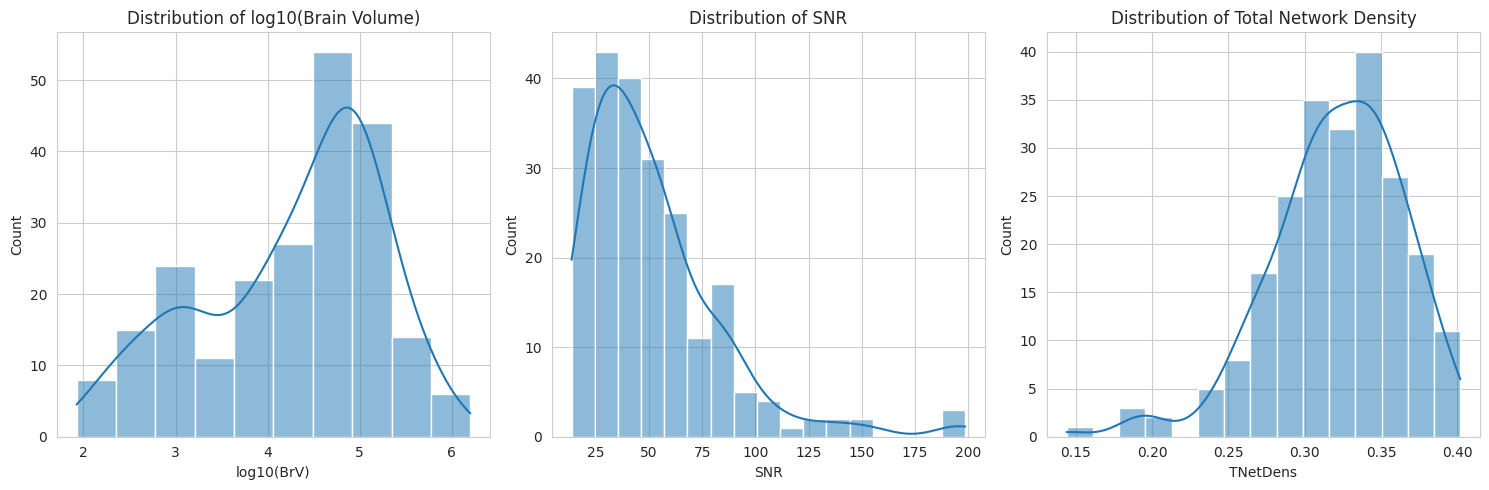


Visualizing counts of a few categorical columns:


/tmp/ipykernel_9075/857540734.py:29: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_9075/857540734.py:33: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




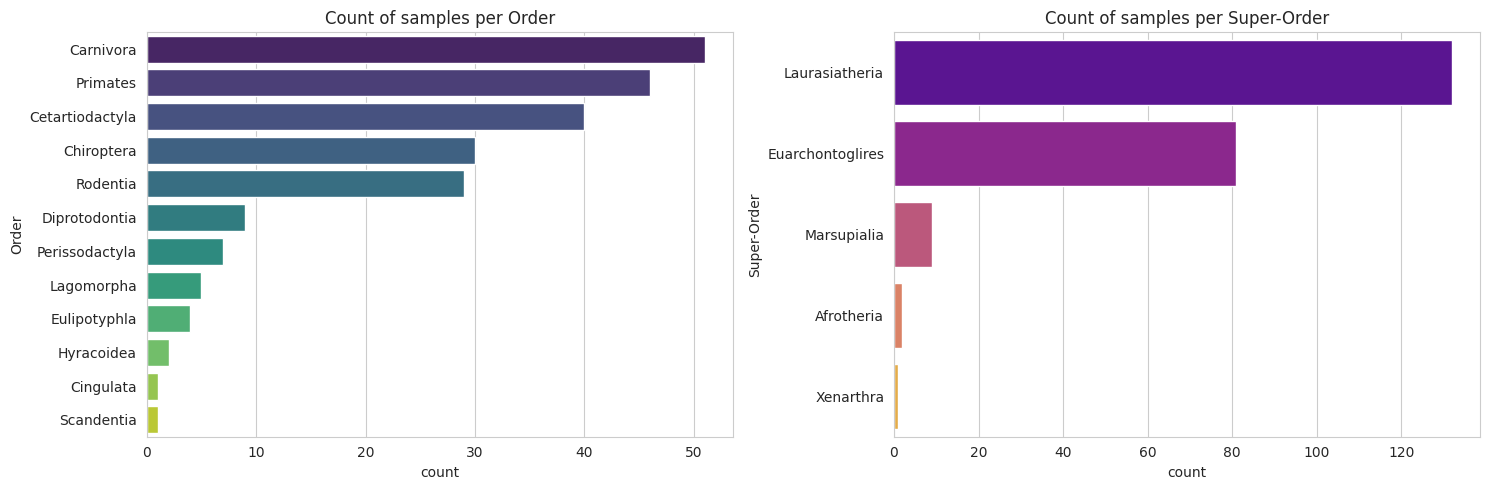


To plot *all* numerical values, a `pairplot` can be used, but it might be very slow and cluttered for all 30+ numerical columns. Here's an example with a subset:


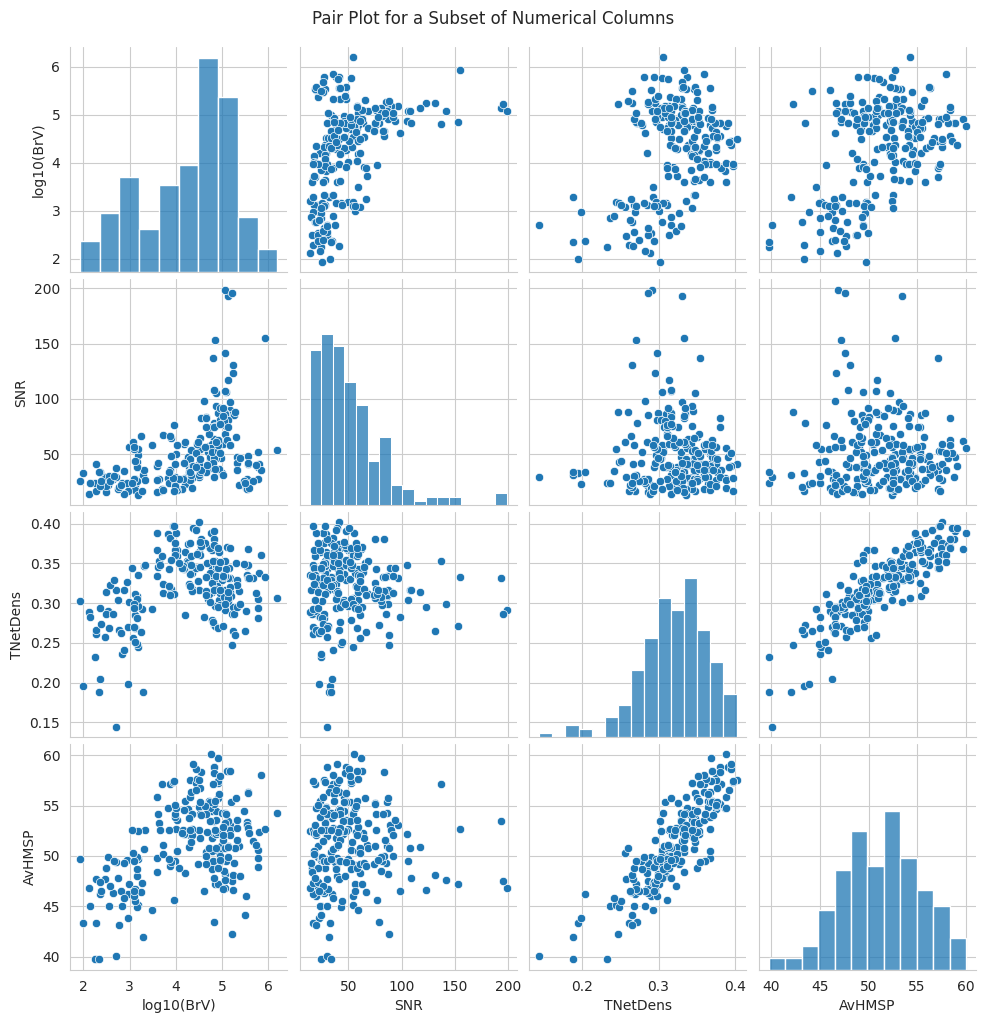


Could you please specify which specific columns or relationships you are interested in visualizing? This will help me create more targeted and informative plots for you.


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

print("Visualizing distributions of a few numerical columns:")
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(unified_df['log10(BrV)'], kde=True)
plt.title('Distribution of log10(Brain Volume)')

plt.subplot(1, 3, 2)
sns.histplot(unified_df['SNR'], kde=True)
plt.title('Distribution of SNR')

plt.subplot(1, 3, 3)
sns.histplot(unified_df['TNetDens'], kde=True)
plt.title('Distribution of Total Network Density')

plt.tight_layout()
plt.show()

print("\nVisualizing counts of a few categorical columns:")
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.countplot(y=unified_df['Order'], order=unified_df['Order'].value_counts().index, palette='viridis')
plt.title('Count of samples per Order')

plt.subplot(1, 2, 2)
sns.countplot(y=unified_df['Super-Order'], order=unified_df['Super-Order'].value_counts().index, palette='plasma')
plt.title('Count of samples per Super-Order')

plt.tight_layout()
plt.show()

print("\nTo plot *all* numerical values, a `pairplot` can be used, but it might be very slow and cluttered for all 30+ numerical columns. Here's an example with a subset:")
# Select a small subset of numerical columns for a pairplot
numerical_cols_subset = ['log10(BrV)', 'SNR', 'TNetDens', 'AvHMSP']
sns.pairplot(unified_df[numerical_cols_subset])
plt.suptitle('Pair Plot for a Subset of Numerical Columns', y=1.02) # Adjust suptitle position
plt.show()

print("\nCould you please specify which specific columns or relationships you are interested in visualizing? This will help me create more targeted and informative plots for you.")

## Data attributes

In [53]:
logvol = unified_df['log10(BrV)']
# brainvol = unified_df["brain_volume"]

In [ ]:
logvol = data['log10_brain_volume']
brainvol = data["brain_volume"]

In [ ]:
# Animal Order
# uses mariagrazia Repo
# 12 possible
animal_order = sio.loadmat('/content/network_modularity_mammalian_connectome/src/mammals_connectome/AnimalOrder.mat')
animal_order["order"]

In [ ]:
# Index of the Animal Order
#uses mariagrazia Repo
order_index = sio.loadmat("/content/network_modularity_mammalian_connectome/src/mammals_connectome/OrderIndex.mat")
order_index['order_index']

# 1 - TDA Analysis of structural connectome

1. Simplicial Distribution
2. Betti Numbers (Conservation measures)


Cosas Importantes:
- La distribución simplicial colapsa la información espacial. No sé donde está cada módulo.

In [11]:
# We need to install igraph
!pip install igraph;

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 48.8 MB/s eta 0:00:00


In [12]:
import networkx as nx
import numpy as np
import pandas as pd
import igraph as ig
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
import os
import scipy.io as sio
import gc

plots_folder = "/content/clique_plots"
os.makedirs(plots_folder, exist_ok=True)

def simplicial_distribution(start_index, end_index,p_cut, connectomes , cliques_df=None):
  """
  Processes connectome data to compute cliques, generate plots, and update a DataFrame.

  Args:
    start_index: The starting index for processing.
    end_index: The ending index for processing.
    cliques_df: (Optional) Existing Pandas DataFrame to append results to.

  Returns:
    pandas.DataFrame: The updated DataFrame with clique data.
  """

  if cliques_df is None:
    cliques_df = pd.DataFrame(columns=['num_simplices', 'max_order_simplex', 'index_study'])


  for index in tqdm(range(start_index, end_index + 1), desc="Processing connectomes"):
    print("index ", index)
    x = connectomes[:, :, index]
    x = x/x.mean()
    x_flat = x.flatten()
    x_flat = np.array(x_flat[x_flat > 0])
    threshold = np.percentile(x_flat, p_cut)
    x[x <= threshold] = 0
    G = nx.from_numpy_array(x)

    G_ig = ig.Graph.TupleList(G.edges(), directed=False)
    # maxs = G_ig.largest_cliques()
    # k_max = np.shape(maxs)[1]
    k_max = G_ig.clique_number()

    if k_max < 18:
      all_cliques = list(tqdm(G_ig.cliques(), desc=f"Finding cliques for index {index}"))
      # Plotting for k_max < 18
      counts = Counter(len(clique) - 1 for clique in all_cliques)
      orders = sorted(counts.keys())
      counts_by_order = [counts[k] for k in orders]

      plt.figure(figsize=(6, 4))
      plt.plot(orders, counts_by_order, marker='o', linestyle='-')
      plt.xlabel("Order (k) of simplex")
      plt.ylabel("Number of simplices")
      plt.title(f"Clique Complex: Simplex Counts by Order,p_cut = {p_cut}, data = {str(connectomes)} , Graph : " + str(index))
      plt.xticks(orders)
      plt.grid(True)
            # Save the plot
      plot_filename = os.path.join(plots_folder, f'clique_plot_{index}.png')
      plt.savefig(plot_filename)
      plt.close()  # Close the figure to prevent display

      df = pd.DataFrame({
        'num_simplices': [np.array(counts_by_order)],
        'max_order_simplex': [len(counts_by_order)],
        'index_study' : [int(index)]
      })

      cliques_df = pd.concat([cliques_df, df])
      gc.collect()
      del all_cliques

    elif k_max < 22:
      # Modified else part for k_max > 17: Store only clique counts
      maxs = G_ig.largest_cliques()
      max_size = np.shape(maxs)[1]

      clique_counts = []  # Store clique counts as a list

      for k in tqdm(range(1, max_size + 1), desc="Processing clique sizes"):
        cliques_k = G_ig.cliques(min=k, max=k)
        num_cliques_of_size_k = len(cliques_k)
        clique_counts.append(num_cliques_of_size_k)
        print(f"Number of cliques of size {k}: {num_cliques_of_size_k}")
        del cliques_k
        gc.collect()

      # Plotting for k_max > 17
      orders = list(range(1, max_size + 1))  # or list(range(max_size))

      plt.figure(figsize=(6, 4))
      plt.plot(orders, clique_counts, marker='o', linestyle='-')
      plt.xlabel("Order (k) of simplex")
      plt.ylabel("Number of simplices")
      plt.title(f"Clique Complex: Simplex Counts by Order,p_cut = {p_cut}, data = {str(connectomes)}, Graph: {index} (k_max > 17)")
      plt.xticks(orders)  # Ensure ticks at each integer order
      plt.grid(True)

      # Save the plot
      plot_filename = os.path.join(plots_folder, f'clique_plot_{index}.png')
      plt.savefig(plot_filename)
      plt.close()

      # Update DataFrame (adapted to use clique_counts list)
      df = pd.DataFrame({
        'num_simplices': [np.array(clique_counts)],
        'max_order_simplex': [max_size],
        'index_study' : [int(index)]
      })

      cliques_df = pd.concat([cliques_df, df])
      gc.collect()

    else:
      print("ORDER BIGGER THAN 22, skipped, ORDER :", k_max)
      continue

  return cliques_df

In [13]:
import math as m

def max_f_k(k, N):
  """
  Computes the máximum number of k-simplices available for a graph of size N.
  max f(k) = C(N, k+1) = N! / [(k+1)! · (N-k-1)!]
  """
  return m.factorial(N) / (  m.factorial(k + 1) * m.factorial(N - k -1)  )


## 1.1 - Simplicial Complexes: Counting Connectomes clique complexes


* We create clique complexes from each graph by thresholding the graph connections to a given value. Beware the fact that the full 200 nodes connectomes overcome the (RAM, since there can be as much as $10^7$ different cliques that saturate memory) computation capacity of google colab, so at least a 25 threshold is needed. The repo provides the data for thresholds of percentiles of 25, 30, and 35 for the value of the normalized connections.

```
code in here
```


* We use the network and igraph python libraries.

* We use the iGraph edges function to count the clique complexes

Processing pipeline:



1.   Normalize graphs so the threshold is equivalent throughout the connectomes
2.   Apply threshold to obtain a binary graph.
3.   Create a graph with from the binary graph using networkx library
4. Compute the number of cliques by using the igraph.Cliques() function.

5. Plot the clique number for each order and save the data in the pandas dataframe.



In [14]:
# from counts_n import process_connectome_data

# connectomes = tensor_50

connectome_150_df_15 = simplicial_distribution(start_index=0, end_index=224 , p_cut = 15, connectomes = tensor_150)


Processing connectomes:   0%|          | 0/225 [00:00<?, ?it/s]

index  0



Processing connectomes:   0%|          | 1/225 [00:01<05:23,  1.45s/it]

index  1



Processing connectomes:   1%|          | 2/225 [00:03<06:02,  1.63s/it]

...


Processing connectomes:  99%|█████████▉| 223/225 [01:48<00:01,  2.00it/s]

index  223



Processing connectomes: 100%|█████████▉| 224/225 [01:49<00:00,  1.98it/s]

index  224



Processing connectomes: 100%|██████████| 225/225 [01:49<00:00,  2.05it/s]


In [15]:
connectome_150_df_15.to_csv("/content/simpl_dist_connectome_150_df_15.csv")

In [24]:
!zip -r clique_plots_norm_15.zip clique_plots;

	zip warning: name not matched: clique_plots

zip error: Nothing to do! (try: zip -r clique_plots_norm_15.zip . -i clique_plots)


### AREA UNDER CURVE

In [ ]:
from sklearn.metrics import auc
import numpy as np

# Supongamos que estos son los datos de tu gráfica
orders = np.array([0, 1, 2, 3, 4, 5]) # Tu eje X
normalized_counts = np.array([1.0, 0.45, 0.12, 0.03, 0.005, 0.001]) # Tu eje Y

# Calcular el AUC
area = auc(orders, normalized_counts)

print(f"El Área Bajo la Curva (AUC) es: {area}")
# Resultado: El Área Bajo la Curva (AUC) es: 1.833

## Connectome data

In [ ]:
#load the necesary functions from the script
from script_crit import process_connectome_data

#compute the clique complexes
supercrit_df_65 = process_connectome_data(start_index=0, end_index=200, p_cut = 65)

#store the final result (a pandas dataframe) as a csv file.
supercrit_df_65.to_csv("supercrit_df_65.csv")

### Plotting the results

### Saving the data as matrices

## Visualization

### Parcellation size effect


In [9]:
df_100   = pd.read_csv('/content/simpl_dist_connectome_50_df_15.csv')
df_200   = pd.read_csv('/content/simpl_dist_connectome_100_df_15.csv')
df_300   = pd.read_csv('/content/simpl_dist_connectome_150_df_15.csv')

In [ ]:
# k_max
for N in [100, 200, 300]:


In [14]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
from math import comb
import ast

df_meta  = unified_df

# df_100   = connectome_50_df_15    #pd.read_csv('results_100.csv')
# df_200   = connectome_100_df_15   #pd.read_csv('results_200.csv')
# df_300   = connectome_150_df_15 #pd.read_csv('results_300.csv')

N_map = {100: 100, 200: 200, 300: 300}  # resolución → número de nodos

# ── 2. PARSEAR num_simplices de string a lista ────────────────────────────────
def parse_fk(s):
    """Convierte '[100 532 543 151 12]' → [100, 532, 543, 151, 12]"""
    s = str(s).strip()
    # elimina corchetes y split por espacios
    nums = s.replace('[', '').replace(']', '').split()
    return [int(x) for x in nums]

for df in [df_100, df_200, df_300]:
    df['fk'] = df['num_simplices'].apply(parse_fk)

# ── 3. FUNCIONES DE MÉTRICAS ──────────────────────────────────────────────────

def calc_kmax_norm(fk, N):
    """k_max / N"""
    k_max = len([x for x in fk if x > 0]) - 1
    return k_max / N

def calc_lambda(fk):
    """
    Tasa de decaimiento exponencial: ajuste log(f(k)) ~ a - lambda*k
    Devuelve (lambda, r²) — r² mide si el decaimiento es realmente exponencial
    """
    ks = np.arange(len(fk))
    log_fk = np.log(np.array(fk, dtype=float) + 1e-10)

    if len(ks) < 3:  # no hay suficientes puntos para ajustar
        return np.nan, np.nan

    slope, intercept, r, p, se = linregress(ks, log_fk)
    return -slope, r**2  # lambda positivo = decaimiento

def calc_chi_norm(fk, N):
    """Característica de Euler normalizada: χ/N"""
    signs = [(-1)**k for k in range(len(fk))]
    chi = sum(s * f for s, f in zip(signs, fk))
    return chi / N

def calc_e2(fk, N):
    """
    Exceso de triángulos sobre modelo ER.
    e(2) = f(2) / E_ER[f(2)]
    E_ER[f(2)] = C(N,3) * p^3  donde p = densidad de aristas observada
    """
    if len(fk) < 3:
        return np.nan

    f1 = fk[1]  # aristas observadas
    f2 = fk[2]  # triángulos observados

    max_edges = comb(N, 2)
    p = f1 / max_edges  # densidad de aristas

    E_ER = comb(N, 3) * (p ** 3)

    if E_ER < 1e-10:  # evitar división por cero
        return np.nan

    return f2 / E_ER

# ── 4. APLICAR MÉTRICAS A CADA RESOLUCIÓN ────────────────────────────────────

def compute_metrics(df_res, N):
    rows = []
    for _, row in df_res.iterrows():
        fk = row['fk']

        lambda_val, r2    = calc_lambda(fk)

        rows.append({
            'index_study' : row['index_study'],
            'k_max_norm'  : calc_kmax_norm(fk, N),
            'lambda'      : lambda_val,
            'lambda_r2'   : r2,       # ← importante: si r²<0.8 el decaimiento no es exponencial
            'chi_norm'    : calc_chi_norm(fk, N),
            'e2'          : calc_e2(fk, N),
            'N'           : N
        })
    return pd.DataFrame(rows)

metrics_100 = compute_metrics(df_100, N=100)
metrics_200 = compute_metrics(df_200, N=200)
metrics_300 = compute_metrics(df_300, N=300)

# ── 5. UNIR CON METADATOS ─────────────────────────────────────────────────────

def merge_with_meta(metrics_df, meta_df):
    return metrics_df.merge(
        meta_df[['Id', 'Species', 'Order', 'log10(BrV)', 'TNetDens', 'GM', 'SNR', 'WM', 'Tcost' , 'TotFib' , 'BR', 'Total Commisures' ]],
        left_on='index_study',
        right_index=True,   # ← asume que el índice de meta coincide con index_study
        how='left'
    )

full_100 = merge_with_meta(metrics_100, df_meta)
full_200 = merge_with_meta(metrics_200, df_meta)
full_300 = merge_with_meta(metrics_300, df_meta)

# Stack de las tres resoluciones juntas (útil para el test de robustez)
full_all = pd.concat([full_100, full_200, full_300], ignore_index=True)

print(full_100.head())
print(full_100.describe())

   index_study  k_max_norm    lambda  lambda_r2  chi_norm        e2    N  Id  \
0            0        0.04  0.549989   0.309487     -0.28  2.705020  100   0   
1            1        0.05  0.540195   0.317505      0.07  2.239534  100   1   
2            2        0.06  0.834701   0.553576     -0.15  2.178036  100   2   
3            3        0.04  0.321061   0.124982      0.21  1.861631  100   3   
4            4        0.05  0.681425   0.417654     -0.05  2.440966  100   4   

                   Species            Order  log10(BrV)  TNetDens         GM  \
0      Addax nasomaculatus  Cetartiodactyla    5.222872   0.24680  136.87000   
1      Dasyprocta leporina         Rodentia    4.261594   0.37459   15.20805   
2      Dasyprocta leporina         Rodentia    4.237016   0.35247   14.36000   
3  Chaetophractus villosus        Cingulata    4.017033   0.36667    9.85000   
4     Artibeus jamaicensis       Chiroptera    2.985696   0.30078    0.83440   

         SNR        WM     Tcost  TotF

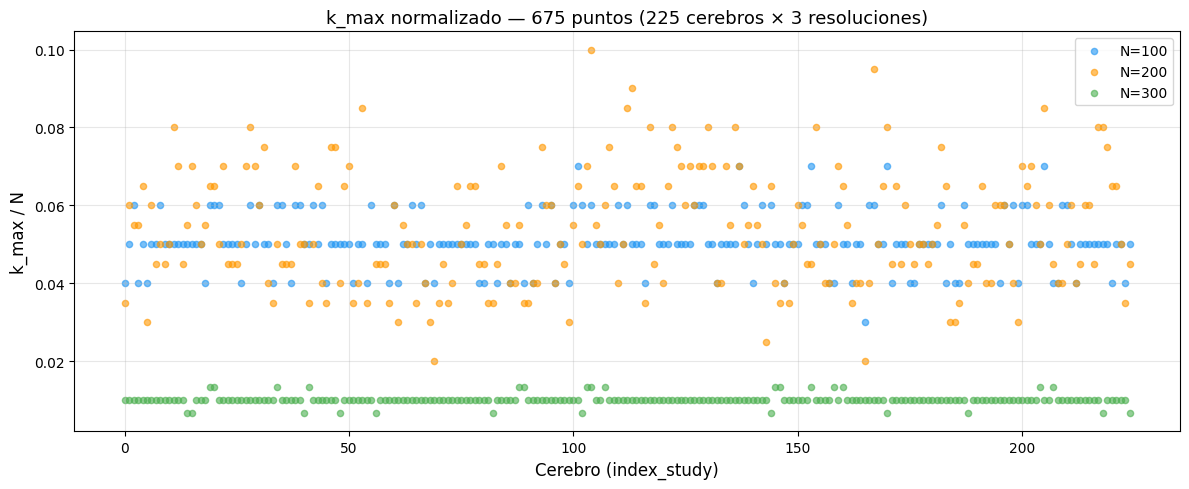

In [36]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 5))

colors = {100: '#2196F3', 200: '#FF9800', 300: '#4CAF50'}

for df, N, label in resolutions:
    ax.scatter(
        df['index_study'],
        df['k_max_norm'],
        color=colors[N],
        label=label,
        alpha=0.6,
        s=20
    )

ax.set_xlabel('Cerebro (index_study)', fontsize=12)
ax.set_ylabel('k_max / N', fontsize=12)
ax.set_title('k_max normalizado — 675 puntos (225 cerebros × 3 resoluciones)', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmax_scatter.png', dpi=150)
plt.show()

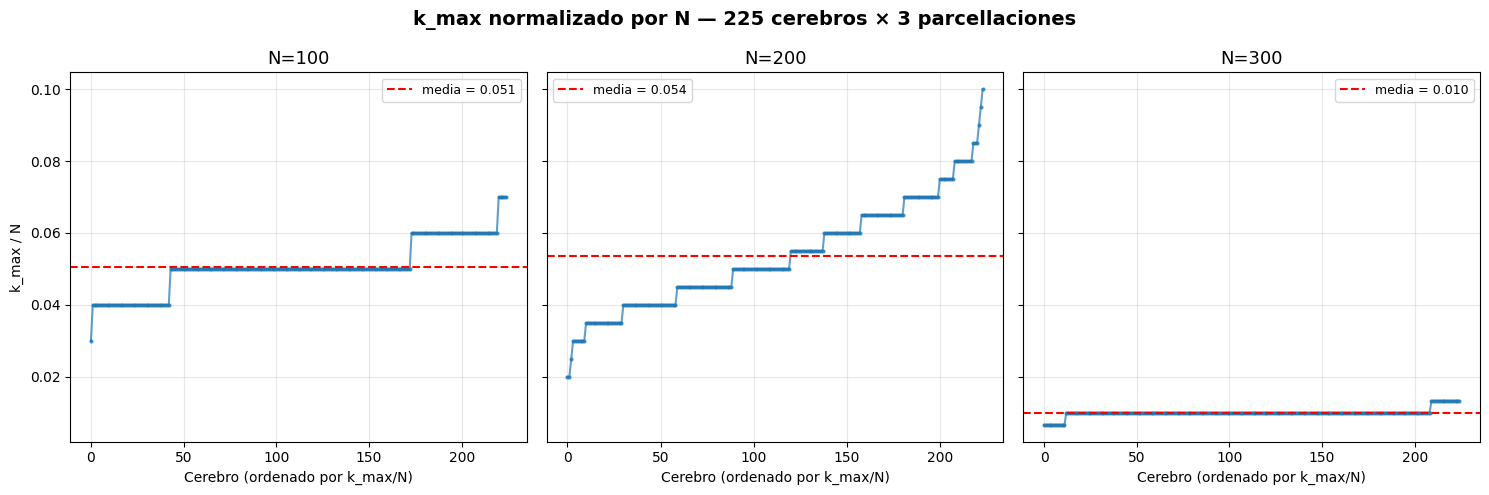

N=100: mean=0.0506  std=0.0071  min=0.0300  max=0.0700
N=200: mean=0.0535  std=0.0149  min=0.0200  max=0.1000
N=300: mean=0.0101  std=0.0012  min=0.0067  max=0.0133


In [35]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

resolutions = [
    (full_100, 100, 'N=100'),
    (full_200, 200, 'N=200'),
    (full_300, 300, 'N=300')
]

for ax, (df, N, label) in zip(axes, resolutions):
    # Ordenar por k_max_norm para ver la distribución claramente
    sorted_vals = df['k_max_norm'].sort_values().values

    ax.plot(sorted_vals, marker='.', linestyle='-', markersize=4, alpha=0.7)
    ax.axhline(sorted_vals.mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'media = {sorted_vals.mean():.3f}')

    ax.set_title(label, fontsize=13)
    ax.set_xlabel('Cerebro (ordenado por k_max/N)', fontsize=10)
    ax.set_ylabel('k_max / N' if N == 100 else '')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('k_max normalizado por N — 225 cerebros × 3 parcellaciones',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kmax_norm_parcellations.png', dpi=150)
plt.show()

# Y los números básicos
for df, N, label in resolutions:
    v = df['k_max_norm']
    print(f"{label}: mean={v.mean():.4f}  std={v.std():.4f}  "
          f"min={v.min():.4f}  max={v.max():.4f}")

In [43]:
df['SNR'] = unified_df['SNR']

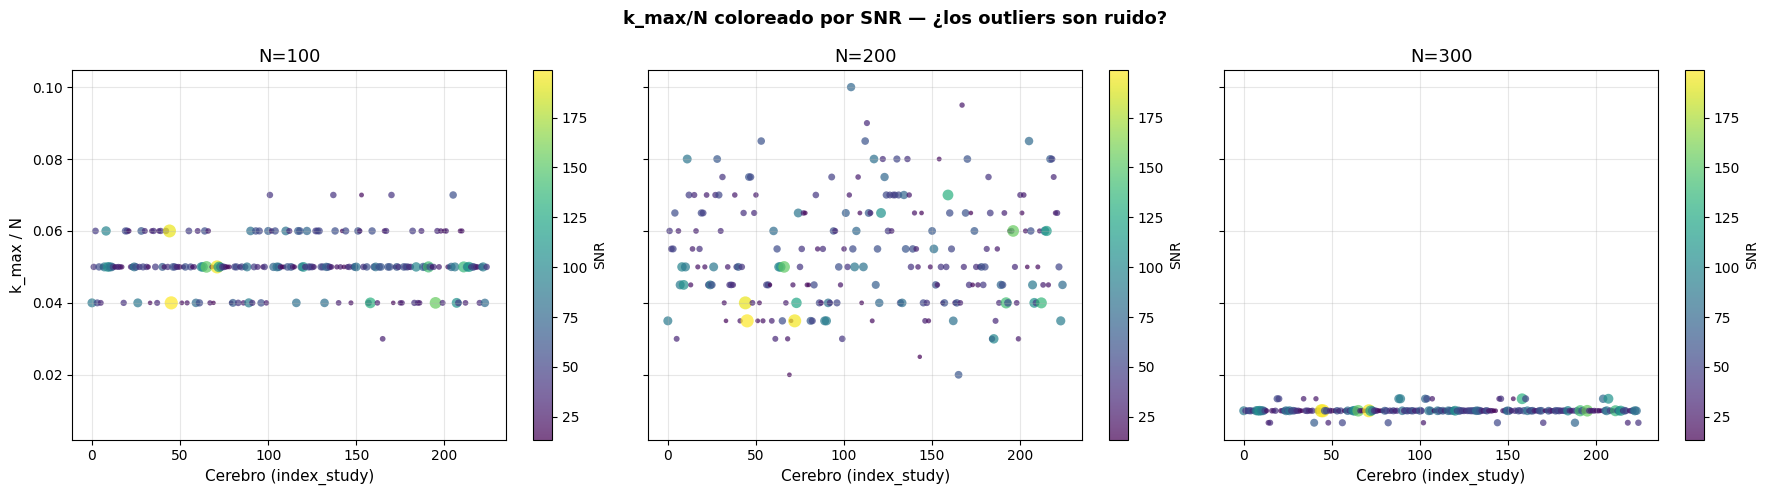

Correlación SNR vs k_max_norm:
  N=100: r = -0.050
  N=200: r = -0.053
  N=300: r = 0.081


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

colors = {100: '#2196F3', 200: '#FF9800', 300: '#4CAF50'}

for ax, (df, N, label) in zip(axes, resolutions):

    df['SNR'] = unified_df['SNR']
    # Normalizar SNR entre 0 y 1 para usar como tamaño de punto
    snr = df['SNR'].values
    snr_norm = (snr - snr.min()) / (snr.max() - snr.min() + 1e-10)
    point_sizes = 10 + snr_norm * 80  # tamaño entre 10 y 90

    sc = ax.scatter(
        df['index_study'],
        df['k_max_norm'],
        c=snr,                    # color = valor absoluto de SNR
        cmap='viridis',
        s=point_sizes,
        alpha=0.7,
        edgecolors='none'
    )

    plt.colorbar(sc, ax=ax, label='SNR')

    ax.set_xlabel('Cerebro (index_study)', fontsize=11)
    ax.set_ylabel('k_max / N' if N == 100 else '', fontsize=11)
    ax.set_title(f'N={N}', fontsize=13)
    ax.grid(True, alpha=0.3)

fig.suptitle('k_max/N coloreado por SNR — ¿los outliers son ruido?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmax_snr.png', dpi=150)
plt.show()

# Correlación entre SNR y k_max_norm para cada resolución
print("Correlación SNR vs k_max_norm:")
for df, N, label in resolutions:
    r = df['SNR'].corr(df['k_max_norm'])
    print(f"  {label}: r = {r:.3f}")

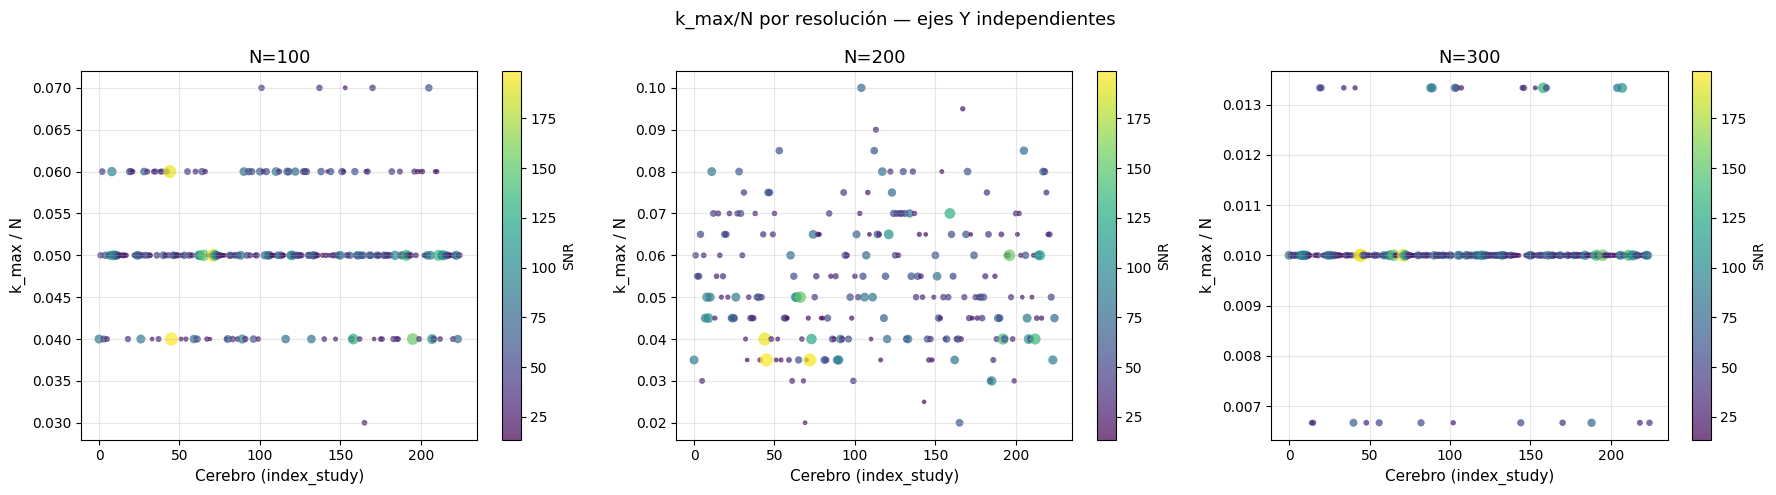

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # sin sharey

for ax, (df, N, label) in zip(axes, resolutions):
    snr = df['SNR'].values
    snr_norm = (snr - snr.min()) / (snr.max() - snr.min() + 1e-10)
    point_sizes = 10 + snr_norm * 80

    sc = ax.scatter(
        df['index_study'],
        df['k_max_norm'],
        c=snr,
        cmap='viridis',
        s=point_sizes,
        alpha=0.7,
        edgecolors='none'
    )
    plt.colorbar(sc, ax=ax, label='SNR')
    ax.set_xlabel('Cerebro (index_study)', fontsize=11)
    ax.set_ylabel('k_max / N', fontsize=11)
    ax.set_title(f'N={N}', fontsize=13)
    ax.grid(True, alpha=0.3)
    # cada panel tiene su propio rango Y automático

fig.suptitle('k_max/N por resolución — ejes Y independientes', fontsize=13)
plt.tight_layout()
plt.savefig('kmax_snr_freeY.png', dpi=150)
plt.show()

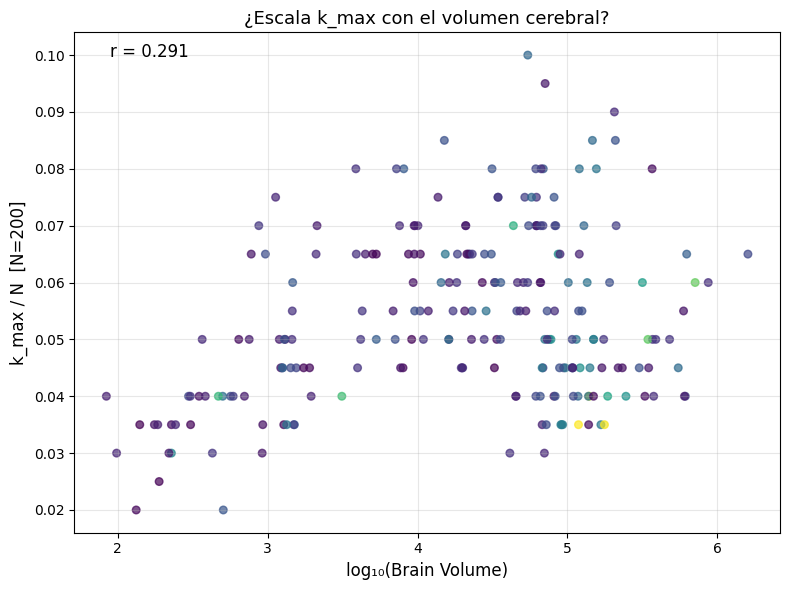

In [49]:
# El scatter más importante hasta ahora
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    full_200['log10(BrV)'],
    full_200['k_max_norm'],
    c=full_200['SNR'],
    cmap='viridis',
    s=30,
    alpha=0.7
)
ax.set_xlabel('log₁₀(Brain Volume)', fontsize=12)
ax.set_ylabel('k_max / N  [N=200]', fontsize=12)
ax.set_title('¿Escala k_max con el volumen cerebral?', fontsize=13)
ax.grid(True, alpha=0.3)

r = full_200['log10(BrV)'].corr(full_200['k_max_norm'])
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig('kmax_vs_brainvol.png', dpi=150)
plt.show()

Coeficiente cuadrático: -0.00544  (negativo = U invertida)
Brain volume en el máximo: log10(BrV) = 4.41  →  BrV = 25714 mm³


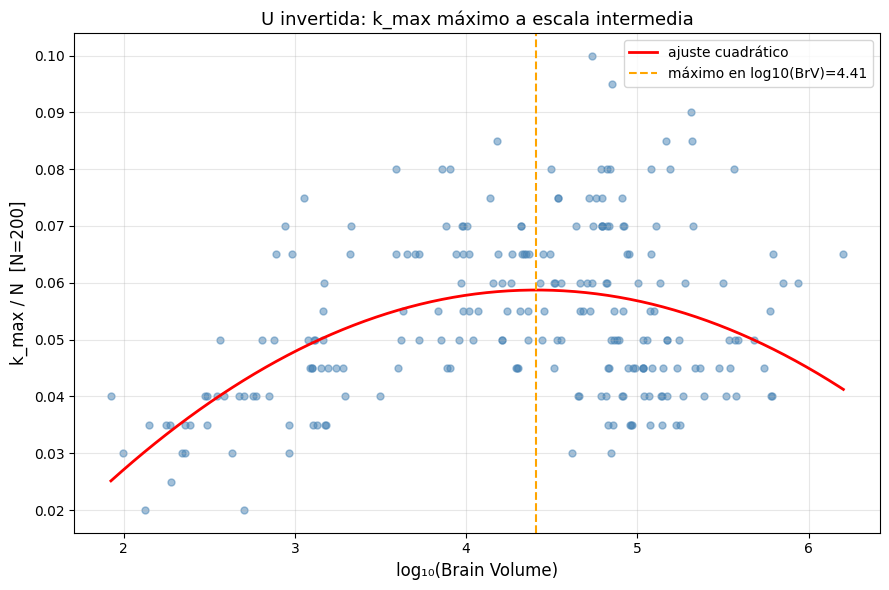

In [50]:
import numpy as np
from scipy.stats import pearsonr

# Ajuste cuadrático para confirmar la U invertida
x = full_200['log10(BrV)'].values
y = full_200['k_max_norm'].values

# Eliminar NaNs
mask = ~(np.isnan(x) | np.isnan(y))
x, y = x[mask], y[mask]

# Ajuste polinomial grado 2
coeffs = np.polyfit(x, y, 2)
p = np.poly1d(coeffs)

# El máximo está en x = -b/2a
x_max = -coeffs[1] / (2 * coeffs[0])
print(f"Coeficiente cuadrático: {coeffs[0]:.5f}  (negativo = U invertida)")
print(f"Brain volume en el máximo: log10(BrV) = {x_max:.2f}  →  BrV = {10**x_max:.0f} mm³")

# Plot con la parábola ajustada
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(x, y, alpha=0.5, s=25, color='steelblue')

x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, p(x_line), color='red', linewidth=2, label=f'ajuste cuadrático')
ax.axvline(x_max, color='orange', linestyle='--',
           label=f'máximo en log10(BrV)={x_max:.2f}')

ax.set_xlabel('log₁₀(Brain Volume)', fontsize=12)
ax.set_ylabel('k_max / N  [N=200]', fontsize=12)
ax.set_title('U invertida: k_max máximo a escala intermedia', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmax_quadratic.png', dpi=150)
plt.show()

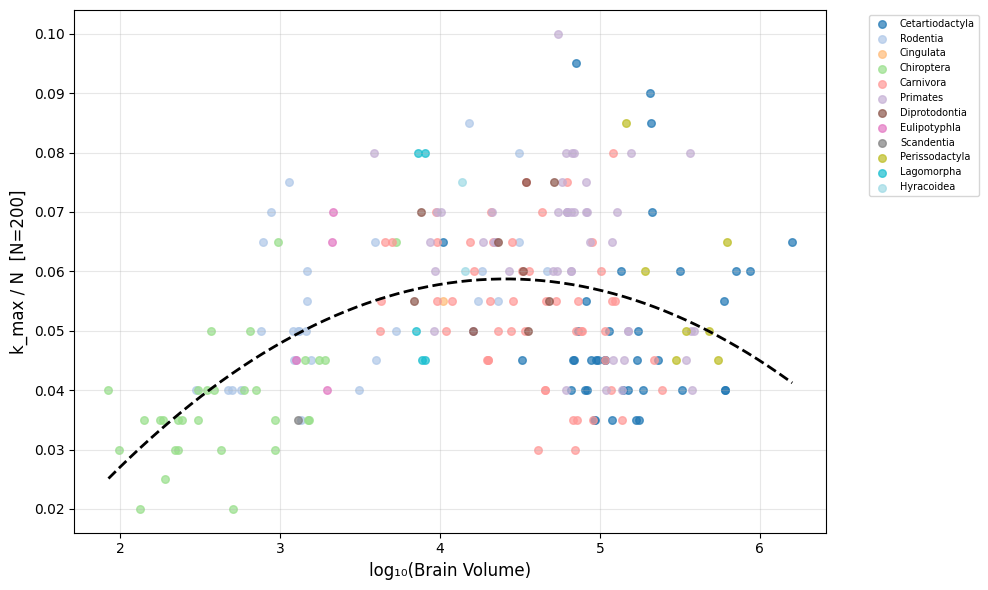

In [51]:
# Colorear por Order taxonómico para ver qué especies están en el pico
orders = full_200['Order'].unique()
colors_tax = plt.cm.tab20(np.linspace(0, 1, len(orders)))
color_map = dict(zip(orders, colors_tax))

fig, ax = plt.subplots(figsize=(10, 6))
for order in orders:
    mask = full_200['Order'] == order
    ax.scatter(
        full_200.loc[mask, 'log10(BrV)'],
        full_200.loc[mask, 'k_max_norm'],
        label=order, s=30, alpha=0.7,
        color=color_map[order]
    )

x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, p(x_line), color='black', linewidth=2, linestyle='--')
ax.set_xlabel('log₁₀(Brain Volume)', fontsize=12)
ax.set_ylabel('k_max / N  [N=200]', fontsize=12)
ax.legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('kmax_by_order.png', dpi=150)
plt.show()

Observación 1 — La varianza aumenta con brain volume
Tienes razón y es una observación más sutil y más interesante que la U invertida. Lo que describes es heterocedasticidad (del griego: varianza no constante) — la dispersión de k_max crece con el volumen.
Interpretación directa: los cerebros pequeños están topológicamente constreñidos — casi todos convergen al mismo k_max independientemente de la especie. Los cerebros grandes tienen libertad topológica — pueden adoptar estrategias muy distintas.
¿Por qué? Piénsalo así:
Un cerebro pequeño tiene pocos recursos (axones, espacio, energía). Hay muy pocas formas de organizar esos recursos que sean viables — el espacio de soluciones es pequeño. Todos los mamíferos pequeños convergen a la misma solución porque es la única eficiente.
Un cerebro grande tiene muchos recursos y muchas formas de organizarlos. Puede ser muy modular (k_max bajo, cliques encerrados) o puede mantener conectividad rica entre módulos (k_max alto). El espacio de soluciones evolutivas se expande.
Esto es análogo a lo que en biología evolutiva se llama canalización — los fenotipos pequeños están canalizados hacia un único resultado, los grandes tienen más grados de libertad evolutivos.


Observación 2 — La U invertida extendida
Dijiste que querías la explicación extendida con consecuencias. Vamos por capas.
¿Qué significa exactamente el máximo en log10(BrV) = 4.41 → ~25.000 mm³?
Eso corresponde aproximadamente a cerebros de gato, mono ardilla, hurón — mamíferos medianos con cerebros relacionalmente complejos pero no gigantes. Justo antes de que la modularidad segregativa empiece a dominar.
La explicación en tres niveles:
Nivel 1 — geométrico: A ese tamaño, la densidad p es suficientemente alta para sostener cliques de orden alto Y suficientemente heterogénea para que algunos nodos estén en muchos cliques (hubs). Es el régimen donde coexisten integración global y especialización local.
Nivel 2 — energético: El paper de Assaf (Nature Neuroscience) encontró que el coste de cableado se conserva across mammals. Para cerebros por debajo del óptimo, el coste es bajo pero la conectividad también — no hay suficiente "presupuesto axonal" para construir cliques grandes. Para cerebros por encima, el coste de mantener conexiones largas obliga a segregar en módulos — los cliques se fragmentan espacialmente.
Nivel 3 — funcional (especulativo pero falseable): Los cliques de orden alto en TDA están relacionados con la capacidad de procesar información de forma integrada y no-redundante. Un k-simplex de orden 5 significa 6 regiones todas mutuamente conectadas — pueden coordinar actividad de formas que no son reducibles a pares. Si k_max refleja esto, el máximo en ~25.000 mm³ podría corresponder a la escala donde la integración funcional es máxima antes de que la modularidad la fragmente.

La pregunta que esto abre — y que puedes responder con tus datos
Si la varianza aumenta con brain volume, ¿qué predice eso sobre los outliers?
Los puntos con k_max muy alto para su tamaño cerebral → cerebros que han evolucionado hacia máxima integración topológica. ¿Qué órdenes son? Míralo:

In [52]:
# Cerebros con k_max muy por encima de la parábola ajustada
full_200['k_max_pred'] = p(full_200['log10(BrV)'].values)
full_200['k_max_residual'] = full_200['k_max_norm'] - full_200['k_max_pred']

top_outliers = full_200.nlargest(15, 'k_max_residual')[
    ['Species', 'Order', 'log10(BrV)', 'k_max_norm', 'k_max_residual']
]
bottom_outliers = full_200.nsmallest(10, 'k_max_residual')[
    ['Species', 'Order', 'log10(BrV)', 'k_max_norm', 'k_max_residual']
]

print("=== Más integrados de lo esperado ===")
print(top_outliers.to_string())
print("\n=== Más modulares de lo esperado ===")
print(bottom_outliers.to_string())

=== Más integrados de lo esperado ===
                   Species            Order  log10(BrV)  k_max_norm  k_max_residual
103     Alouatta seniculus         Primates    4.735359       0.100        0.041851
166             Sus scrofa  Cetartiodactyla    4.851075       0.095        0.037333
112             Lama glama  Cetartiodactyla    5.312917       0.090        0.035710
111             Lama glama  Cetartiodactyla    5.319476       0.085        0.030775
204     Tapirus terrestris   Perissodactyla    5.166371       0.085        0.029387
153         Pongo pygmaeus         Primates    5.564512       0.080        0.028526
53        Myocastor coypus         Rodentia    4.178919       0.085        0.026567
218      Rattus norvegicus         Rodentia    3.053883       0.075        0.026285
135       Cebuella pygmaea         Primates    3.588832       0.080        0.024946
11         Papio hamadryas         Primates    5.192651       0.080        0.024607
19      Tursiops truncatus  Cetartioda

In [53]:
print("=== Más integrados de lo esperado ===")
print(top_outliers.to_string())

=== Más integrados de lo esperado ===
                   Species            Order  log10(BrV)  k_max_norm  k_max_residual
103     Alouatta seniculus         Primates    4.735359       0.100        0.041851
166             Sus scrofa  Cetartiodactyla    4.851075       0.095        0.037333
112             Lama glama  Cetartiodactyla    5.312917       0.090        0.035710
111             Lama glama  Cetartiodactyla    5.319476       0.085        0.030775
204     Tapirus terrestris   Perissodactyla    5.166371       0.085        0.029387
153         Pongo pygmaeus         Primates    5.564512       0.080        0.028526
53        Myocastor coypus         Rodentia    4.178919       0.085        0.026567
218      Rattus norvegicus         Rodentia    3.053883       0.075        0.026285
135       Cebuella pygmaea         Primates    3.588832       0.080        0.024946
11         Papio hamadryas         Primates    5.192651       0.080        0.024607
19      Tursiops truncatus  Cetartioda

In [56]:
# Comparar lobo vs perro doméstico
canids = full_200[full_200['Species'].str.contains('Canis')][
    ['Species', 'log10(BrV)', 'k_max_norm', 'k_max_residual']
]
print(canids.sort_values('k_max_residual'))
# ```

# ---

### La pregunta más importante ahora

# ¿Qué te salió en los más integrados? Porque si son primates — tenemos una historia evolutiva muy limpia:
# ```
# Cerebros pequeños → constreñidos, todos iguales
# Carnívoros/ungulados → modulares, por debajo de la tendencia
# Primates/cetáceos → integrados, por encima de la tendencia
# Cerebros muy grandes → vuelven a ser modulares por coste energético

                    Species  log10(BrV)  k_max_norm  k_max_residual
60   Canis lupus familiaris    4.846213       0.030       -0.027690
58   Canis lupus familiaris    4.831235       0.035       -0.022760
64   Canis lupus familiaris    4.858838       0.035       -0.022629
222             Canis lupus    4.956024       0.035       -0.022103
62   Canis lupus familiaris    4.879383       0.050       -0.007526
63   Canis lupus familiaris    4.890030       0.050       -0.007471
221             Canis lupus    5.031408       0.050       -0.006624
61   Canis lupus familiaris    4.864392       0.055       -0.002602
59   Canis lupus familiaris    5.005695       0.060        0.003205
220             Canis lupus    4.950316       0.065        0.007863


In [34]:
import matplotlib.pyplot as plt

# Para el mismo cerebro, ¿varía lambda entre resoluciones?
pivot = full_all.pivot_table(
    index='index_study',
    columns='N',
    values='lambda'
)

# Correlación entre resoluciones
print(pivot.corr())

# Si la correlación 100↔300 es > 0.9 → lambda es robusto a la parcellación

N         100       200       300
N                                
100  1.000000  0.209836 -0.059480
200  0.209836  1.000000  0.195273
300 -0.059480  0.195273  1.000000


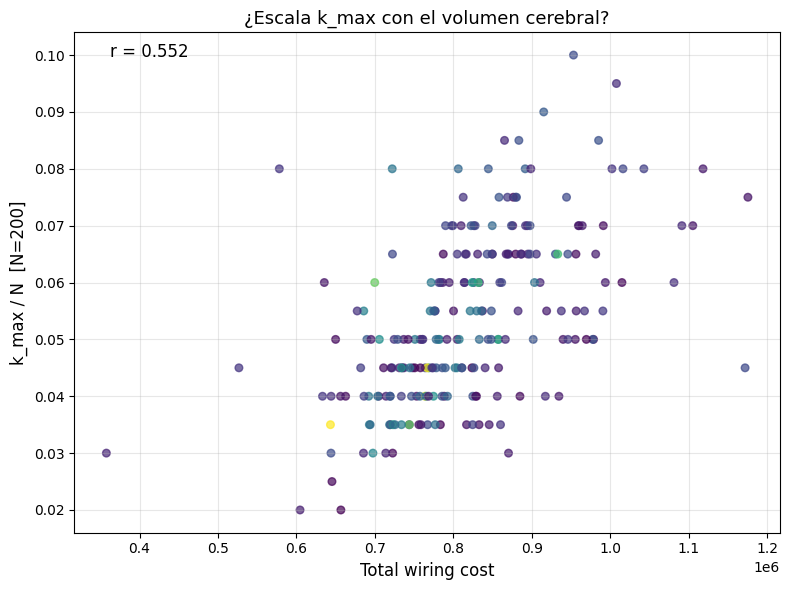

In [15]:
# El scatter más importante hasta ahora
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    full_200['Tcost'],
    full_200['k_max_norm'],
    c=full_200['SNR'],
    cmap='viridis',
    s=30,
    alpha=0.7
)
ax.set_xlabel('Total wiring cost', fontsize=12)
ax.set_ylabel('k_max / N  [N=200]', fontsize=12)
ax.set_title('¿Escala k_max con el volumen cerebral?', fontsize=13)
ax.grid(True, alpha=0.3)

r = full_200['Tcost'].corr(full_200['k_max_norm'])
ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig('kmax_vs_Tcost.png', dpi=150)
plt.show()

## 1.2 - Persistence Homology: Betti Numbers Computation

In [5]:
!pip install igraph
!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 43.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 40.0 MB/s eta 0:00:00


In [6]:
!pip install --upgrade gudhi

In [7]:
# import networkx as nx
# import numpy as np
# import pandas as pd
# import igraph as ig
# from tqdm import tqdm
# from collections import Counter
# import matplotlib.pyplot as plt
# import os
# import scipy.io as sio
# import gc
# import gudhi as gd

# # threshold = 0.3
# # percentile_cut = 10

# # 1. Load the data:
# # data_file_path = '/content/SCmatrices_mammals.mat'  # Replace with your actual file path
# # data = sio.loadmat(data_file_path)



# def create_persistence(start_index, end_index, p_cut, connectomes ,betti_df=None ):
#   """
#   Processes connectome data to compute cliques, generate plots, and update a DataFrame.

#   Args:
#     start_index: The starting index for processing.
#     end_index: The ending index for processing.
#     cliques_df: (Optional) Existing Pandas DataFrame to append results to.

#   Returns:
#     pandas.DataFrame: The updated DataFrame with clique data.
#   """
#   # Create a folder to save the plots
#   plots_folder = '/content/persistence_plots_' + str(p_cut)
#   os.makedirs(plots_folder, exist_ok=True)

#   if betti_df is None:
#     betti_df = pd.DataFrame(columns=['betti_numbers', 'index_study'])

#   for index in tqdm(range(start_index, end_index + 1), desc="Processing connectomes"):
#     print("index ", index)
#     x = connectomes[:, :, index]
#     x = x/x.mean()
#     x_flat = x.flatten()
#     x_flat = np.array(x_flat[x_flat > 0])
#     threshold = np.percentile(x_flat, p_cut)
#     x[x <= threshold] = 0
#     G = nx.from_numpy_array(x)

#     G_ig = ig.Graph.TupleList(G.edges(), directed=False)
#     k_max = G_ig.clique_number()

#     in_matrix = x
#     # Convert to networkx graph
#     G_nx = nx.from_numpy_array(in_matrix)

#     # Convert to igraph for efficient clique finding
#     G_ig = ig.Graph.TupleList(G_nx.edges(), directed=False)

#     # Create a SimplexTree
#     simplex_tree = gd.SimplexTree()

#     # Insert vertices
#     for i in range(in_matrix.shape[0]):
#         simplex_tree.insert([i], filtration=0)

#     # Find and insert cliques as higher-dimensional simplices
#     max_clique_size = G_ig.clique_number()  # Get maximum clique size

#     for k in range(2, max_clique_size + 1):  # Iterate through clique sizes
#         cliques_of_size_k = G_ig.cliques(min=k, max=k)
#         for clique in cliques_of_size_k:
#             # Get the maximum weight of edges within the clique for filtration value
#             max_weight = 0
#             for i in range(len(clique)):
#                 for j in range(i + 1, len(clique)):
#                     weight = in_matrix[clique[i], clique[j]]
#                     max_weight = max(max_weight, weight)

#             simplex_tree.insert(clique, filtration=max_weight)  # Insert clique with filtration

#     # Now you have a SimplexTree with higher-dimensional simplices.
#     # You can compute persistence, Betti numbers, etc.
#     persistence = simplex_tree.persistence()
#     gd.plot_persistence_barcode(persistence)

#     # plt.figure(figsize=(6, 4))

#     plt.xlabel("Normalized Weight Connection")
#     plt.ylabel("Cavity order")

#     plot_filename = os.path.join(plots_folder, f'persistence_plot_{index}.png')
#     plt.savefig(plot_filename)
#     plt.close()  # Close the figure to prevent display

#     df = pd.DataFrame({
#       'betti_numbers': [simplex_tree.betti_numbers()],
#       'index_study' : [int(index)]
#     })

#     betti_df = pd.concat([betti_df, df])
#     gc.collect()
#     del simplex_tree

#   return betti_df

import networkx as nx
import numpy as np
import pandas as pd
import igraph as ig
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
import gc
import gudhi as gd
import json

def save_checkpoint(betti_df, last_index, p_cut, checkpoint_dir='/content/checkpoints'):
    os.makedirs(checkpoint_dir, exist_ok=True)
    betti_df.to_csv(f'{checkpoint_dir}/betti_pcut_{p_cut}.csv', index=False)
    with open(f'{checkpoint_dir}/meta_pcut_{p_cut}.json', 'w') as f:
        json.dump({'last_index': last_index}, f)
    print(f"✓ Checkpoint guardado: índice {last_index}")

def load_checkpoint(p_cut, checkpoint_dir='/content/checkpoints'):
    df_path = f'{checkpoint_dir}/betti_pcut_{p_cut}.csv'
    meta_path = f'{checkpoint_dir}/meta_pcut_{p_cut}.json'

    if os.path.exists(df_path) and os.path.exists(meta_path):
        betti_df = pd.read_csv(df_path)
        betti_df['betti_numbers'] = betti_df['betti_numbers'].apply(eval)
        with open(meta_path, 'r') as f:
            last_index = json.load(f)['last_index']
        print(f"✓ Continuando desde índice {last_index + 1}")
        return betti_df, last_index
    return pd.DataFrame(columns=['betti_numbers', 'index_study']), -1

def create_persistence(start_index, end_index, p_cut, connectomes,
                       checkpoint_interval=2, resume=True):

    plots_folder = f'/content/persistence_plots_{p_cut}'
    os.makedirs(plots_folder, exist_ok=True)

    # Cargar checkpoint si existe
    if resume:
        betti_df, last_processed = load_checkpoint(p_cut)
        start_index = max(start_index, last_processed + 1)
    else:
        betti_df = pd.DataFrame(columns=['betti_numbers', 'index_study'])

    if start_index > end_index:
        print("✓ Ya completado")
        return betti_df

    for index in tqdm(range(start_index, end_index + 1), desc="Processing"):
        # Tu código original
        x = connectomes[:, :, index].copy()
        x = x / x.mean()
        x_flat = x.flatten()
        x_flat = np.array(x_flat[x_flat > 0])
        threshold = np.percentile(x_flat, p_cut)
        x[x <= threshold] = 0

        G = nx.from_numpy_array(x)
        G_ig = ig.Graph.TupleList(G.edges(), directed=False)

        # Crear SimplexTree
        simplex_tree = gd.SimplexTree()

        # Insertar vértices
        for i in range(x.shape[0]):
            simplex_tree.insert([i], filtration=0)

        # Insertar cliques
        max_clique_size = G_ig.clique_number()
        for k in range(2, max_clique_size + 1):
            cliques_of_size_k = G_ig.cliques(min=k, max=k)
            for clique in cliques_of_size_k:
                max_weight = 0
                for i in range(len(clique)):
                    for j in range(i + 1, len(clique)):
                        weight = x[clique[i], clique[j]]
                        max_weight = max(max_weight, weight)
                simplex_tree.insert(clique, filtration=max_weight)

        # Persistencia y plot
        persistence = simplex_tree.persistence()
        betti_numbers = simplex_tree.betti_numbers()

        gd.plot_persistence_barcode(persistence)
        plt.xlabel("Normalized Weight Connection")
        plt.ylabel("Cavity order")
        plt.savefig(f'{plots_folder}/persistence_plot_{index}.png')
        plt.close('all')

        # Guardar resultado
        new_row = pd.DataFrame({
            'betti_numbers': [betti_numbers],
            'index_study': [int(index)]
        })
        betti_df = pd.concat([betti_df, new_row], ignore_index=True)

        # Limpieza
        del simplex_tree, persistence, G, G_ig, x
        gc.collect()

        # Checkpoint periódico
        if (index + 1) % checkpoint_interval == 0:
            save_checkpoint(betti_df, index, p_cut)

    # Checkpoint final
    save_checkpoint(betti_df, end_index, p_cut)
    return betti_df

In [18]:
filtration_betti_conn_100_pcut_15_df = create_persistence(
    start_index=0,
    end_index=224,
    p_cut=15,  # percentile cut
    connectomes=tensor_100,
    checkpoint_interval=2,  # Guarda cada 5 conectomas
    resume=True
)

#falla en el índice 54


# # Save the summary DataFrame with one row per connectome
# subcrit_betti_df_65.to_csv(
#     '/content/drive/MyDrive/Psicología/CONECTOMAS/CP/subcrit_betti_df_65.csv',
#     index=False
# )

Processing:   0%|          | 0/225 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/gudhi/persistence_graphical_tools.py:150: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")
Processing:   1%|          | 2/225 [00:40<1:25:24, 22.98s/it]

✓ Checkpoint guardado: índice 1


Processing:   2%|▏         | 4/225 [01:06<1:00:20, 16.38s/it]

✓ Checkpoint guardado: índice 3


Processing:   3%|▎         | 6/225 [01:14<32:56,  9.03s/it]

...

✓ Checkpoint guardado: índice 51


Processing:  24%|██▍       | 54/225 [27:12<6:09:26, 129.63s/it]

✓ Checkpoint guardado: índice 53


Processing:  24%|██▍       | 55/225 [42:45<2:12:08, 46.64s/it]


KeyboardInterrupt: 

In [ ]:
filtration_betti_conn_100_pcut_15_df.to_csv('/content/filtration_betti_conn_100_pcut_15_df.csv')

In [ ]:
filtraion_betti_conn_100_pcut_15_df.to_csv

#### Ripser

In [8]:
!pip install ripser persim

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.1 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=fed6d32ed95fdc8af2aecfcd95c6f68e32ee93158a262c49dd088dc29acc1433
  Stored in directory: /root/.cache/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp


In [5]:
#para eliminar. No funciona

# import numpy as np
# from ripser import ripser
# from persim import plot_diagrams
# import pandas as pd
# import matplotlib.pyplot as plt
# import os
# import gc
# from tqdm import tqdm
# import json
# #para calcular la dimensión más grande
# import igraph as ig
# import networkx as nx

# def save_checkpoint(betti_df, last_index, p_cut, checkpoint_dir='/content/checkpoints'):
#     os.makedirs(checkpoint_dir, exist_ok=True)
#     betti_df.to_csv(f'{checkpoint_dir}/betti_pcut_{p_cut}.csv', index=False)
#     with open(f'{checkpoint_dir}/meta_pcut_{p_cut}.json', 'w') as f:
#         json.dump({'last_index': last_index}, f)
#     print(f"✓ Checkpoint guardado: índice {last_index}")

# def load_checkpoint(p_cut, checkpoint_dir='/content/checkpoints'):
#     df_path = f'{checkpoint_dir}/betti_pcut_{p_cut}.csv'
#     meta_path = f'{checkpoint_dir}/meta_pcut_{p_cut}.json'

#     if os.path.exists(df_path) and os.path.exists(meta_path):
#         betti_df = pd.read_csv(df_path)
#         betti_df['betti_numbers'] = betti_df['betti_numbers'].apply(eval)
#         with open(meta_path, 'r') as f:
#             last_index = json.load(f)['last_index']
#         print(f"✓ Continuando desde índice {last_index + 1}")
#         return betti_df, last_index
#     return pd.DataFrame(columns=['betti_numbers', 'index_study']), -1

# def create_persistence_ripser(start_index, end_index, p_cut, connectomes,
#                                max_dim=None, checkpoint_interval=5, resume=True):
#     """
#     Calcula persistencia usando Ripser (eficiente en memoria).

#     Args:
#         max_dim: Dimensión máxima de homología (2 = hasta H2/cavidades)
#     """
#     plots_folder = f'/content/persistence_plots_{p_cut}'
#     os.makedirs(plots_folder, exist_ok=True)

#     if resume:
#         betti_df, last_processed = load_checkpoint(p_cut)
#         start_index = max(start_index, last_processed + 1)
#     else:
#         betti_df = pd.DataFrame(columns=['betti_numbers', 'index_study'])

#     if start_index > end_index:
#         print("✓ Ya completado")
#         return betti_df

#     for index in tqdm(range(start_index, end_index + 1), desc="Processing"):
#         # Preprocesar igual que antes
#         x = connectomes[:, :, index].copy()
#         x = x / x.mean()
#         x_flat = x[x > 0].flatten()
#         threshold = np.percentile(x_flat, p_cut)
#         x[x <= threshold] = 0

#         # Si max_dim=None, calcular el clique máximo primero
#         if max_dim is None:

#             G = nx.from_numpy_array(x)
#             G_ig = ig.Graph.TupleList(G.edges(), directed=False)
#             actual_max_dim = G_ig.clique_number() - 1  # clique de tamaño k -> dimensión k-1
#             del G, G_ig
#         else:
#             actual_max_dim = max_dim

#         # Convertir pesos a distancias para Ripser
#         max_weight = x.max()
#         distances = np.where(x > 0, max_weight - x, np.inf)
#         np.fill_diagonal(distances, 0)

#         # Ripser - eficiente en memoria
#         result = ripser(distances, maxdim=max_dim, distance_matrix=True)

#         # Extraer números de Betti (features que nunca mueren)
#         betti_numbers = []
#         for dgm in result['dgms']:
#             n_infinite = np.sum(np.isinf(dgm[:, 1]))
#             betti_numbers.append(n_infinite)

#         # Plot
#         plt.figure(figsize=(8, 5))
#         plot_diagrams(result['dgms'], show=False)
#         plt.title(f'Connectome {index}')
#         plt.savefig(f'{plots_folder}/persistence_plot_{index}.png')
#         plt.close('all')

#         # Guardar
#         new_row = pd.DataFrame({
#             'betti_numbers': [betti_numbers],
#             'index_study': [int(index)]
#         })
#         betti_df = pd.concat([betti_df, new_row], ignore_index=True)

#         del result, distances, x
#         gc.collect()

#         if (index + 1) % checkpoint_interval == 0:
#             save_checkpoint(betti_df, index, p_cut)

#     save_checkpoint(betti_df, end_index, p_cut)
#     return betti_df

In [11]:
# Tu código original
# index = 33
p_cut = 15
connectomes = tensor_100
order_sizes = []

for index in range(225):
  x = connectomes[:, :, index].copy()
  x = x / x.mean()
  x_flat = x.flatten()
  x_flat = np.array(x_flat[x_flat > 0])
  threshold = np.percentile(x_flat, p_cut)
  x[x <= threshold] = 0

  G = nx.from_numpy_array(x)
  G_ig = ig.Graph.TupleList(G.edges(), directed=False)

  # Crear SimplexTree
  simplex_tree = gd.SimplexTree()

  # Insertar vértices
  for i in range(x.shape[0]):
      simplex_tree.insert([i], filtration=0)

  # Insertar cliques
  max_clique_size = G_ig.clique_number()
  order_sizes.append(max_clique_size)
  # print(max_clique_size)

# for k in range(2, max_clique_size + 1):
#     cliques_of_size_k = G_ig.cliques(min=k, max=k)
#     for clique in cliques_of_size_k:
#         max_weight = 0
#         for i in range(len(clique)):
#             for j in range(i + 1, len(clique)):
#                 weight = x[clique[i], clique[j]]
#                 max_weight = max(max_weight, weight)
#         simplex_tree.insert(clique, filtration=max_weight)

# # Persistencia y plot
# persistence = simplex_tree.persistence()
# betti_numbers = simplex_tree.betti_numbers()

HAY QUE OPTIMIZAR EL Código para que funcione con órdenes de hasta 23...es posible ? o simplemente eliminamos estos outliers ?

In [16]:
order_sizes.index(23)

55

In [11]:
betti_numbers

[2, 26, 285, 82, 0, 0, 0]

In [ ]:
# Preprocesar igual que antes
# import igraph as ig
# import networkx as nx

# max_dim = None

# x = connectomes[:, :, index].copy()
# x = x / x.mean()
# x_flat = x[x > 0].flatten()
# threshold = np.percentile(x_flat, p_cut)
# x[x <= threshold] = 0

# # Si max_dim=None, calcular el clique máximo primero
# if max_dim is None:
#     G = nx.from_numpy_array(x)
#     G_ig = ig.Graph.TupleList(G.edges(), directed=False)
#     actual_max_dim = G_ig.clique_number() - 1  # clique de tamaño k -> dimensión k-1
#     del G, G_ig
# else:
#     actual_max_dim = max_dim

# # Convertir pesos a distancias para Ripser
# max_weight = x.max()
# distances = np.where(x > 0, max_weight - x, np.inf)
# np.fill_diagonal(distances, 0)

# # Ripser - eficiente en memoria
# result = ripser(distances, maxdim=actual_max_dim, distance_matrix=True)

# # Extraer números de Betti (features que nunca mueren)
# betti_numbers2 = []
# for dgm in result['dgms']:
#     n_infinite = np.sum(np.isinf(dgm[:, 1]))
#     betti_numbers2.append(n_infinite)

# 2 - TDA for Contact Process Activity Correlations Outputs.

Same analysis as before only that the input data is the correlation of activity in the connectome obtained with the contact process model. There are three types of inputs depending on the activity regime that produced the correlations: supercritical, critical and subcritical.

For the details of how these were obtained refer to the Contact Process notebok in the repo:

In [ ]:
%cat /content/persistence_curves.py

In [ ]:
!sed -i "s/gudhi.SimplexTree.create_from_networkx/gudhi.SimplexTree.from_networkx/g" /content/persistence_curves.py

# Brain Regions Visualization

In [ ]:
# This code is for downloading the whole dataset (beware it is heavy, around 9 GB)
# # Install the package
# !pip install zenodo_get;

# # # Download all files from that specific Zenodo record ID
# !zenodo_get 7143143;

# # # This downloads all files in the Zenodo repository

# !unzip -q raw_results.zip

In [ ]:
# import os

# def find_nii_files(start_dir):
#     nii_files = []
#     for root, _, files in os.walk(start_dir):
#         for file in files:
#             if file.endswith(('.nii', '.nii.gz')):
#                 nii_files.append(os.path.join(root, file))
#     return nii_files

# raw_results_path = '/content/raw_results/'

# if os.path.exists(raw_results_path):
#     found_nii_files = find_nii_files(raw_results_path)
#     if found_nii_files:
#         print("Found .nii or .nii.gz files in raw_results:")
#         for f in found_nii_files:
#             print(f)
#     else:
#         print("No .nii or .nii.gz files found in raw_results.")
# else:
#     print(f"The folder '{raw_results_path}' does not exist.")

No .nii or .nii.gz files found in raw_results.


In [ ]:
# !pip install BrainGlobe-atlasapi
# !pip install brainrender bg-atlasapi

# #rendering required for colab
# !pip install k3d

!pip install bg-atlasapi trimesh meshio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 10.9 MB/s eta 0:00:00


In [ ]:
brain_atlas_availability = {
    # CATEGORY 1: Direct Python Access (BrainGlobe bg-atlasapi)
    "brainglobe_ready": [
        'Cat', 'Mouse', 'Rat', 'Vole', 'WildRat' # WildRat can be safely scaled to the Rat atlas
    ],

    # CATEGORY 2: Known to exist, requires downloading a .nii.gz file from external repos
    "external_download_required": [
        'Baboon', 'Capuchin', 'Chimpanzee', 'Cow', 'Dog', 'Ferret',
        'Goat', 'Gorilla', 'GreenMonkey', 'Horse', 'Macaque',
        'Marmoset', 'Orangutan', 'Porcine', 'Rabbit', 'Sheep',
        'SkinnyPig', 'SquirrelMonkey', 'Vervet', 'WildBoar', 'WildRabbit'
    ],

    # CATEGORY 3: Standard 3D atlases likely do not exist (Must use Plotly 3D Point Clouds)
    "wild_zoo_plotly_only": [
        'Addax', 'Agouti', 'Armadillo', 'ArtibeusJamacien', 'Asellia',
        'AsianOtter', 'BactrianDeer', 'Battongia', 'BlanfordFox', 'BlindMole',
        'BottleNoseDolphin', 'BrownLemur', 'CapraNubiana', 'Capybara', 'Caracal',
        'CarolliaPerspicilatta', 'CaucasianSquirrel', 'ChaerephonPlicata', 'Chinchila',
        'Chital', 'Colobus', 'CommonFox', 'CommonHedgeHog', 'CommonTreeShrew',
        'Coypu', 'Cynopterus', 'Deer', 'Dego', 'DikDik', 'Donkey',
        'Eonycteris', 'Eptesicus', 'FallowDeer', 'FennekFox', 'FruitBat',
        'Gerbil', 'Giraffe', 'GoldenSpinyMouse', 'GrayKangaroo', 'Hare',
        'HimalianBear', 'HippArmiger', 'HoneyBadger', 'HowlerMonkey', 'Hyaena',
        'Hyrax', 'IndHogDeer', 'JungleCat', 'Koala', 'Lama',
        'LemurCatta', 'Leopard', 'Lycaon', 'Mandrill', 'Mangebi',
        'Mara', 'Meerkat', 'Merion', 'MiniopterusSchreibersii', 'Mongoose',
        'MyotisEmargenitus', 'MyotisMyotis', 'MyotisVivesi', 'Nasua', 'Onager',
        'Oryx', 'Otter', 'PalmSquirrel', 'Pecari', 'Pkuhlii',
        'Porcupine', 'PrairieDog', 'PteropusLylei', 'RedKangaroo', 'RedNeckWallaby',
        'RedPanda', 'Rhinolophus', 'Rhinopoma', 'SandCat', 'SandHedgeHog',
        'Siamang', 'SpinyMouse', 'StrippedDolphin', 'SturniraLilium', 'TadaridaTeniotis',
        'TamarinCottonTop', 'TamarinEmperor', 'TamarinGoldenHands', 'Tapir', 'ThomsonGazelle',
        'Tiger', 'VampireBat', 'Wilderbeest', 'Wolf', 'Zebra'
    ]
}

In [ ]:
import bg_atlasapi
bg_atlasapi.show_atlases()

╭───────────────────────────────── Brainglobe Atlases ─────────────────────────────────╮
│                                                                           Latest     │
│  Name                              Downloaded  Updated  Local version    version     │
│  csl_cat_500um                         ✔          ✔          1.0           1.0       │
│  example_mouse_100um                                                       1.2       │
│  allen_mouse_10um                                                          1.2       │
│  allen_mouse_25um                                                          1.2       │
│  allen_mouse_50um                                                          1.2       │
│  allen_mouse_100um                                                         1.2       │
│  mpin_zfish_1um                                                            1.0       │
│  allen_human_500um                                                         1.0       │
│  kim_mouse_10um                                                            1.1       │
│  kim_mouse_25um                                                            1.1       │
│  kim_mouse_50um                                                            1.1       │
│  kim_mouse_100um                                                           1.1       │
│  osten_mouse_10um                                                          1.1       │
│  osten_mouse_25um                                                          1.1       │
│  osten_mouse_50um                                                          1.1       │
│  osten_mouse_100um                                                         1.1       │
│  allen_cord_20um                                                           1.2       │
│  azba_zfish_4um                                                            1.2       │
│  whs_sd_rat_39um                                                           1.2       │
│  perens_lsfm_mouse_20um                                                    1.2       │
│  admba_3d_e11_5_mouse_16um                                                 1.1       │
│  admba_3d_e13_5_mouse_16um                                                 1.1       │
│  admba_3d_e15_5_mouse_16um                                                 1.1       │
│  admba_3d_e18_5_mouse_16um                                                 1.1       │
│  admba_3d_p4_mouse_16.752um                                                1.1       │
│  admba_3d_p14_mouse_16.752um                                               1.1       │
│  admba_3d_p28_mouse_16.752um                                               1.1       │
│  admba_3d_p56_mouse_25um                                                   1.1       │
│  princeton_mouse_20um                                                      1.1       │
│  kim_dev_mouse_e11-5_lsfm_20um                                             1.3       │
│  kim_dev_mouse_e11-5_mri-adc_31.…                                          1.3       │
│  kim_dev_mouse_e11-5_mri-dwi_31.…                                          1.3       │
│  kim_dev_mouse_e11-5_mri-fa_31.5…                                          1.3       │
│  kim_dev_mouse_e11-5_mri-t2_31.5…                                          1.3       │
│  kim_dev_mouse_e13-5_lsfm_20um                                             1.3       │
│  kim_dev_mouse_e13-5_mri-adc_34um                                          1.3       │
│  kim_dev_mouse_e13-5_mri-dwi_34um                                          1.3       │
│  kim_dev_mouse_e13-5_mri-fa_34um                                           1.3       │
│  kim_dev_mouse_e13-5_mri-t2_34um                                           1.3       │
│  kim_dev_mouse_e15-5_lsfm_20um                                             1.3       │
│  kim_dev_mouse_e15-5_mri-adc_37.…                                          1.3       │
│  kim_dev_mouse_e15-5_mri-dwi_37.…                                          1.3    

In [ ]:
cat_coords = np.load('/content/data/connectivity/mami/coords/Cat1.npy')

In [ ]:
import numpy as np
import plotly.graph_objects as go
from bg_atlasapi.bg_atlas import BrainGlobeAtlas

# =========================================================
# 1. LOAD THE ATLAS (Cat Brain)
# =========================================================
# This will download the atlas the first time (if not already downloaded)
print("Loading Cat Atlas...")
atlas = BrainGlobeAtlas("csl_cat_500um")

# Extract the 3D mesh of the entire brain ("root")
# Corrected: Use atlas.mesh property for the whole brain mesh
mesh = atlas.root_mesh()

# BrainGlobe uses different mesh formats depending on the version.
# This try/except ensures we get the vertices (points) and faces (triangles) safely.
try:
    # If trimesh format
    vertices = mesh.vertices
    faces = mesh.faces
except AttributeError:
    # If meshio format
    vertices = mesh.points
    faces = mesh.cells_dict.get("triangle", mesh.cells[0].data)

# =========================================================
# 2. LOAD & ALIGN YOUR ZENODO DATA
# =========================================================
print("Aligning Coordinates...")
# Mocking your (200, 3) Zenodo coordinates
zenodo_coords = np.random.uniform(low=-10, high=10, size=(200, 3))


# Find the physical boundaries of the Cat Brain mesh
brain_min = vertices.min(axis=0)
brain_max = vertices.max(axis=0)
brain_size = brain_max - brain_min

# Find the boundaries of your Zenodo points
coords_min = cat_coords.min(axis=0)
coords_max = cat_coords.max(axis=0)

# Step A: Normalize points to be exactly between 0.0 and 1.0
normalized_coords = (cat_coords - coords_min) / (coords_max - coords_min)

# Step B: Scale them to fit inside the Cat brain (using 85% of the size for padding)
padding_factor = 0.85
scaled_coords = normalized_coords * (brain_size * padding_factor)

# Step C: Shift the points so they are centered inside the brain volume
offset = brain_min + (brain_size * ((1.0 - padding_factor) / 2))
final_coords = scaled_coords + offset

# =========================================================
# 3. DRAW THE 3D SCENE WITH PLOTLY
# =========================================================
print("Rendering Plotly figure...")
fig = go.Figure()

# --- Draw the Transparent "Glass Brain" ---
fig.add_trace(go.Mesh3d(
    x=vertices[:, 0],
    y=vertices[:, 1],
    z=vertices[:, 2],
    i=faces[:, 0],
    j=faces[:, 1],
    k=faces[:, 2],
    color='lightgray',
    opacity=0.15,      # Make it highly transparent so we can see inside!
    hoverinfo='skip',  # Don't show tooltip when hovering over the brain shell
    name='Cat Brain'
))

# --- Draw the 200 Brain Regions (Nodes) ---
# Let's generate some mock values to color the nodes (e.g., node degree)
node_values = np.random.rand(200)

fig.add_trace(go.Scatter3d(
    x=final_coords[:, 0],
    y=final_coords[:, 1],
    z=final_coords[:, 2],
    mode='markers',
    marker=dict(
        size=6,
        color=node_values,       # Color the dots by their value
        colorscale='Plasma',     # Beautiful color map ('Viridis', 'Plasma', 'Inferno')
        colorbar=dict(title="Metric"),
        opacity=1.0,
        line=dict(width=1, color='black') # Subtle outline on the dots
    ),
    text=[f"Node {i}<br>Value: {node_values[i]:.2f}" for i in range(200)], # Hover text
    hoverinfo='text',
    name='Brain Nodes'
))

# --- Formatting the Layout ---
fig.update_layout(
    title='Cat Brain Network (Scaled to Atlas)',
    width=700,
    height=600,
    scene=dict(
        aspectmode='data', # CRUCIAL: Keeps the 3D proportions biologically accurate!
        xaxis=dict(visible=False), # Hide the grid lines for a cleaner look
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
    ),
    margin=dict(l=0, r=0, b=0, t=50) # Remove empty whitespace
)

# Show the interactive plot!
fig.show()

Loading Cat Atlas...
Aligning Coordinates...
Rendering Plotly figure...


# Task
Identifica el archivo que está presente en las carpetas `/content/MaMI_dataset/data/connectivity/mami/conn_50/` y `/content/MaMI_dataset/data/connectivity/mami/conn_150/` pero que no está en la carpeta `/content/MaMI_dataset/data/connectivity/mami/conn_100/`, y luego reporta el nombre de ese archivo.

## List Files in Directories

### Subtask:
Obtener las listas de todos los archivos en las carpetas `/content/MaMI_dataset/data/connectivity/mami/conn_50/`, `/content/MaMI_dataset/data/connectivity/mami/conn_100/` y `/content/MaMI_dataset/data/connectivity/mami/conn_150/`.


**Reasoning**:
The subtask requires listing files in three specified directories. I will use the `os` module to achieve this, defining each folder path and then filtering for files.



In [ ]:
import os

# Define the path for the conn_50 folder
folder_path_conn_50 = '/content/data/connectivity/mami/conn_50/'
# Get a list of all files in the conn_50 folder
files_conn_50 = [f for f in os.listdir(folder_path_conn_50) if os.path.isfile(os.path.join(folder_path_conn_50, f))]
print(f"Number of files in '{folder_path_conn_50}': {len(files_conn_50)}")

# Define the path for the conn_100 folder
folder_path_conn_100 = '/content/data/connectivity/mami/conn_100/'
# Get a list of all files in the conn_100 folder
files_conn_100 = [f for f in os.listdir(folder_path_conn_100) if os.path.isfile(os.path.join(folder_path_conn_100, f))]
print(f"Number of files in '{folder_path_conn_100}': {len(files_conn_100)}")

# Define the path for the conn_150 folder
folder_path_conn_150 = '/content/data/connectivity/mami/conn_150/'
# Get a list of all files in the conn_150 folder
files_conn_150 = [f for f in os.listdir(folder_path_conn_150) if os.path.isfile(os.path.join(folder_path_conn_150, f))]
print(f"Number of files in '{folder_path_conn_150}': {len(files_conn_150)}")

Number of files in '/content/data/connectivity/mami/conn_50/': 226
Number of files in '/content/data/connectivity/mami/conn_100/': 225
Number of files in '/content/data/connectivity/mami/conn_150/': 226


**Reasoning**:
Now that the lists of files for each directory are available, I will convert them to sets to efficiently find the file that exists in `conn_50` and `conn_150` but not in `conn_100` using set operations.



In [ ]:
set_files_conn_50 = set(files_conn_50)
set_files_conn_100 = set(files_conn_100)
set_files_conn_150 = set(files_conn_150)

# Find files present in conn_50 and conn_150
intersection_50_150 = set_files_conn_50.intersection(set_files_conn_150)

# Find files in the intersection that are NOT in conn_100
missing_file = intersection_50_150.difference(set_files_conn_100)

if missing_file:
    print(f"The file present in '/content/MaMI_dataset/data/connectivity/mami/conn_50/' and '/content/MaMI_dataset/data/connectivity/mami/conn_150/' but not in '/content/MaMI_dataset/data/connectivity/mami/conn_100/' is: {missing_file.pop()}")
else:
    print("No such file found.")

The file present in '/content/MaMI_dataset/data/connectivity/mami/conn_50/' and '/content/MaMI_dataset/data/connectivity/mami/conn_150/' but not in '/content/MaMI_dataset/data/connectivity/mami/conn_100/' is: SandHedghHog.npy


In [ ]:
len(set_files_conn_150.intersection(set_files_conn_50))

226

In [ ]:
set_files_conn_150.symmetric_difference(set_files_conn_50)

set()

In [ ]:
len(set_files_conn_50.intersection(set_files_conn_100))

216

In [ ]:
len(set_files_conn_150.intersection(set_files_conn_100))

216

In [ ]:
len(set_files_conn_150.symmetric_difference(set_files_conn_100))

19

In [ ]:
set_files_conn_150.symmetric_difference(set_files_conn_100)

{'Cynnopterus.npy',
 'Cynopterus.npy',
 'Mongoose.npy',
 'Moongose.npy',
 'MyotisVivesi2.npy',
 'Pkhulii2.npy',
 'Pkhulii3.npy',
 'Pkuhlii2.npy',
 'Pkuhlii3.npy',
 'SandHedgeHog.npy',
 'SandHedghHog.npy',
 'Tiger.npy',
 'Tigris.npy',
 'WildBoar1.npy',
 'WildRabbit.npy',
 'WildRabbit1.npy',
 'WildRat.npy',
 'WildRat1.npy',
 'Wildboar1.npy'}

In [ ]:
set_files_conn_50.symmetric_difference(set_files_conn_100)

{'Cynnopterus.npy',
 'Cynopterus.npy',
 'Mongoose.npy',
 'Moongose.npy',
 'MyotisVivesi2.npy',
 'Pkhulii2.npy',
 'Pkhulii3.npy',
 'Pkuhlii2.npy',
 'Pkuhlii3.npy',
 'SandHedgeHog.npy',
 'SandHedghHog.npy',
 'Tiger.npy',
 'Tigris.npy',
 'WildBoar1.npy',
 'WildRabbit.npy',
 'WildRabbit1.npy',
 'WildRat.npy',
 'WildRat1.npy',
 'Wildboar1.npy'}

In [ ]:
print(set_files_conn_50.symmetric_difference(set_files_conn_100))
print(set_files_conn_150.difference(set_files_conn_100))

{'Pkhulii3.npy', 'WildRabbit1.npy', 'MyotisVivesi2.npy', 'Wildboar1.npy', 'Pkuhlii3.npy', 'SandHedghHog.npy', 'Moongose.npy', 'Pkhulii2.npy', 'WildBoar1.npy', 'Tiger.npy', 'Cynnopterus.npy', 'WildRabbit.npy', 'SandHedgeHog.npy', 'Mongoose.npy', 'Pkuhlii2.npy', 'Tigris.npy', 'WildRat.npy', 'Cynopterus.npy', 'WildRat1.npy'}
{'SandHedghHog.npy', 'WildRat.npy', 'MyotisVivesi2.npy', 'Cynnopterus.npy', 'Pkhulii2.npy', 'Pkhulii3.npy', 'WildRabbit.npy', 'Tigris.npy', 'Moongose.npy', 'Wildboar1.npy'}


In [ ]:
set_files_conn_50

{'Addax.npy',
 'Agouti1.npy',
 'Agouti2.npy',
 'Armadillo.npy',
 'ArtibeusJamacien.npy',
 'Asellia.npy',
 'AsianOtter.npy',
 'Baboon1.npy',
 'Baboon2.npy',
 'Baboon3.npy',
 'Baboon4.npy',
 'Baboon5.npy',
 'BactrianDeer1.npy',
 'BactrianDeer2.npy',
 'Battongia1.npy',
 'Battongia2.npy',
 'BlanfordFox.npy',
 'BlindMole1.npy',
 'BlindMole2.npy',
 'BottleNoseDolphin.npy',
 'BrownLemur1.npy',
 'BrownLemur2.npy',
 'BrownLemur3.npy',
 'CapraNubiana1.npy',
 'CapraNubiana2.npy',
 'CapraNubiana3.npy',
 'CapraNubiana4.npy',
 'Capuchin1.npy',
 'Capuchin2.npy',
 'Capuchin3.npy',
 'Capybara.npy',
 'Caracal.npy',
 'CarolliaPerspicilatta1.npy',
 'CarolliaPerspicilatta2.npy',
 'Cat1.npy',
 'Cat2.npy',
 'Cat3.npy',
 'Cat4.npy',
 'Cat5.npy',
 'Cat6.npy',
 'CaucasianSquirrel.npy',
 'ChaerephonPlicata.npy',
 'Chimpanzee.npy',
 'Chinchila.npy',
 'Chital1.npy',
 'Chital2.npy',
 'Colobus2.npy',
 'CommonFox.npy',
 'CommonHedgeHog1.npy',
 'CommonHedgeHog2.npy',
 'CommonHedgeHog3.npy',
 'CommonTreeShrew.npy',
 'C